# Notebook 07 — σ_e clean radial-bin pipeline

Fresh σ_e measurement for the M•–σ relation, with every step transparent.

**Method summary:**
1. R_e measured independently from F140W (masked), F200LP (masked), IFU 6500-7500 Å white-light (unmasked).
2. Deflector center from HST F140W and F200LP 2-D Gaussian centroids (mask-aware).
3. Radial annuli (5 bins, edges at [0, R_e/8, R_e/4, R_e/2, 3R_e/4, R_e]) on the IFU grid.
4. Per-annulus ppxf bootstrap with all three SPS libraries (FSPS, EMILES, XSL), per-SPS V_sys offset.
5. Explicit Gültekin integral σ_e² = Σ F_j × (V_j² + σ_j²) / Σ F_j with F_j = ∫ I(r) 2πr dr.
6. Physical prior check: σ(r) should DECREASE with R; annuli violating this are flagged as arc-contaminated.

No PowerBin. No HST-mask application to the I-weight (the `_mask.fits` files cover the deflector core, not just the arc — rejected in nb06).

**Run modes:**
- Smoke (N=10, 6 degrees): ~3 min
- Full (N=500, 15 degrees): ~1.5 h

In [2]:
import os, sys
from time import perf_counter as clock

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.cosmology import FlatLambdaCDM
from scipy.ndimage import gaussian_filter, map_coordinates
from tqdm import tqdm

from ppxf.ppxf import ppxf

sys.path.insert(0, os.path.abspath('..'))
from scripts.bootstrap_ppxf import (
    setup_ppxf_inputs_from_spectrum, run_bootstrap_single_degree,
    NOISE_SLICE, C_KMS,
)
from scripts.measure_Re import measure_Re_from_profile

try:
    from photutils.centroids import centroid_2dg, centroid_com
except ImportError:
    centroid_2dg = None
    centroid_com = None

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=12)

In [3]:
# ══════════════════════════════════════════════
# Configuration — smoke vs full
# ══════════════════════════════════════════════
IFU_FILE   = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
HST_F140W  = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3.fits'
HST_F140W_MASK = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3_mask.fits'
HST_F200LP = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3.fits'
HST_F200LP_MASK = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3_mask.fits'
RESULTS_DIR = '../results'
ANNULAR_DIR = '../results/annular_bootstrap'
FIG_DIR = '../results/figures'
os.makedirs(ANNULAR_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Science config
Z_SYSTEMIC = 0.67564
SPS_LIBS = ['fsps', 'emiles', 'xsl']

# Smoke test default — FLIP TO FULL-MODE values to produce paper headline numbers
N_BOOTSTRAP = 500         # FULL
DEGREES = np.arange(15, 30)  # FULL: 15 degrees
BOOT_SEED = 42
WINDOW = 75
N_MC = 500                 # Gültekin MC draws from bootstrap posteriors (cheap)

# Contamination threshold for the weighting mask (applied to annular spectrum
# extraction only — NOT to the I(r) weight).
KCWI_SEEING_FWHM = 1.27
HST_PIXSCALE_F140W = 0.08
CONTAM_THRESHOLD = 0.15

# Annulus edges — set after R_e is measured in §3
# Preview: 5 bins at [0, Re/8, Re/4, Re/2, 3Re/4, Re]

# Cosmology (for kpc conversions)
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
KPC_PER_ARCSEC = COSMO.kpc_proper_per_arcmin(Z_SYSTEMIC).value / 60

print(f'N_BOOTSTRAP={N_BOOTSTRAP}, DEGREES={DEGREES[0]}..{DEGREES[-1]} ({len(DEGREES)} vals)')
print(f'z_systemic={Z_SYSTEMIC}, kpc/arcsec={KPC_PER_ARCSEC:.3f}')

N_BOOTSTRAP=500, DEGREES=15..29 (15 vals)
z_systemic=0.67564, kpc/arcsec=7.044


## §1. Load data

Load the IFU cube, F140W and F200LP cutouts and their masks. No reprojection yet.

In [4]:
# IFU cube
with fits.open(IFU_FILE) as h:
    hdr = h[0].header; cube = h[0].data.astype(float)
wcs_ifu = WCS(hdr, naxis=2)
ny, nx = cube.shape[1], cube.shape[2]
crval = hdr['CRVAL3']; cdelt = hdr['CD3_3']; crpix = hdr.get('CRPIX3', 1.0)
lam = crval + cdelt * (np.arange(hdr['NAXIS3']) + 1 - crpix)
pix_scale_ifu = float(np.abs(proj_plane_pixel_scales(wcs_ifu)[0])) * 3600
print(f'IFU cube: {cube.shape}, λ={lam[0]:.0f}-{lam[-1]:.0f} Å, pix={pix_scale_ifu:.3f}\"/spaxel')

# IFU 6500-7500 Å band sum (our preferred I-weight)
band_mask = (lam >= 6500) & (lam <= 7500)
ifu_band = np.sum(cube[band_mask, :, :], axis=0)
print(f'IFU 6500-7500 Å band: {band_mask.sum()} channels, image sum={ifu_band.sum():.3e}')

# HST F140W cutout + mask
with fits.open(HST_F140W) as h:
    img_f140 = h[0].data.astype(float); hdr_f140 = h[0].header
wcs_f140 = WCS(hdr_f140)
mask_f140 = fits.getdata(HST_F140W_MASK).astype(bool)
pix_scale_f140 = float(np.abs(proj_plane_pixel_scales(wcs_f140)[0])) * 3600
print(f'F140W: {img_f140.shape}, pix={pix_scale_f140:.3f}\"/pix, mask covers {mask_f140.sum()} pix')

# HST F200LP
with fits.open(HST_F200LP) as h:
    img_f200 = h[0].data.astype(float); hdr_f200 = h[0].header
wcs_f200 = WCS(hdr_f200)
mask_f200 = fits.getdata(HST_F200LP_MASK).astype(bool)
pix_scale_f200 = float(np.abs(proj_plane_pixel_scales(wcs_f200)[0])) * 3600
print(f'F200LP: {img_f200.shape}, pix={pix_scale_f200:.3f}\"/pix, mask covers {mask_f200.sum()} pix')

IFU cube: (3317, 100, 100), λ=5625-8941 Å, pix=0.300"/spaxel
IFU 6500-7500 Å band: 1001 channels, image sum=4.439e+03
F140W: (312, 312), pix=0.080"/pix, mask covers 1121 pix
F200LP: (500, 500), pix=0.050"/pix, mask covers 2512 pix


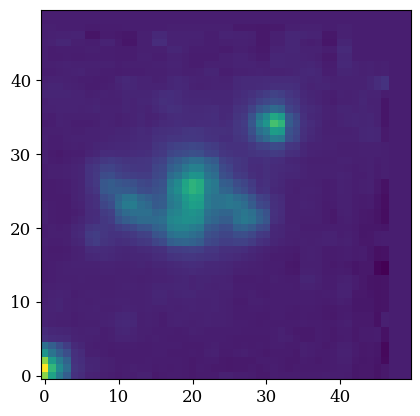

In [5]:
band_mask_ = (lam >= 6000) & (lam <= 7500)
ifu_band_ = np.sum(cube[band_mask_, :, :], axis=0)

plt.imshow(ifu_band_[30:80, 30:80], origin = 'lower')

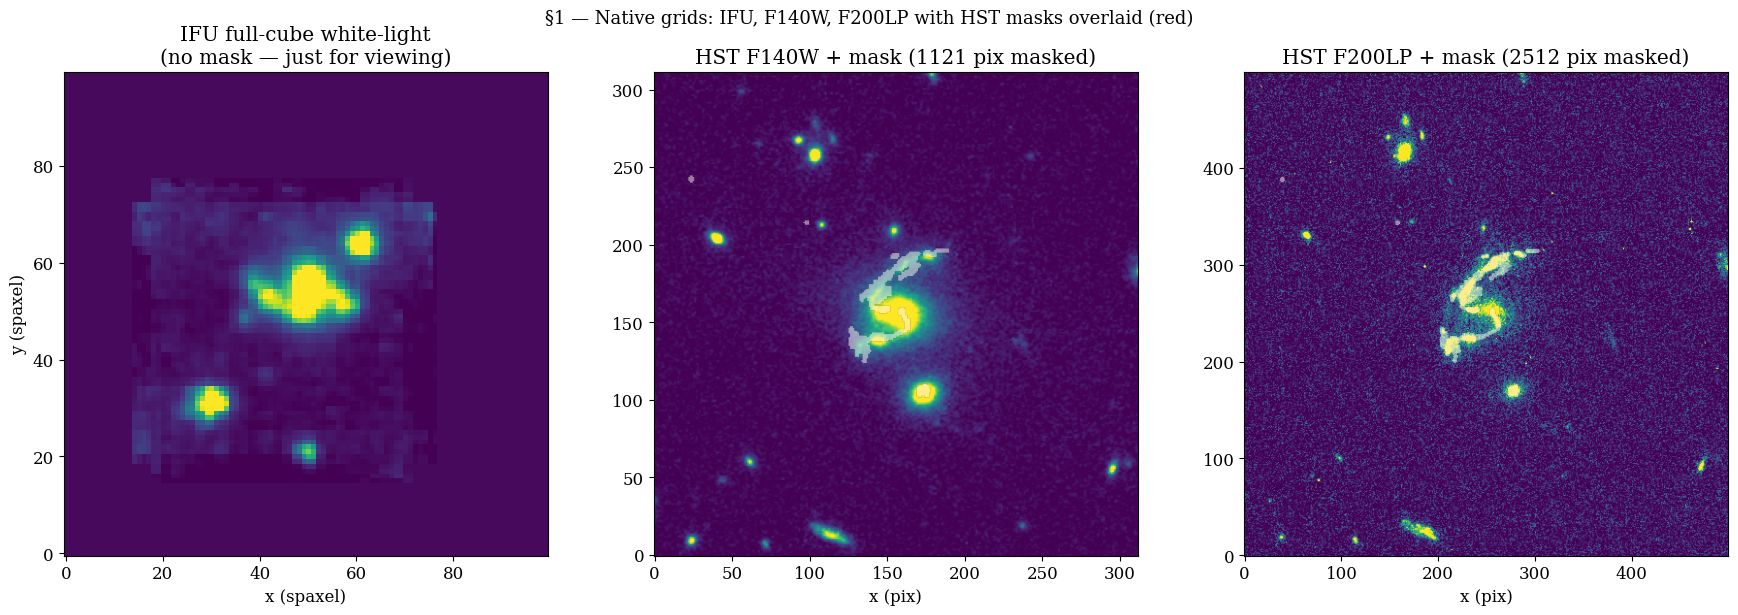

In [6]:
# Plot §1: the three images with mask overlays
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
wl_full = np.sum(cube, axis=0)
axes[0].imshow(wl_full, origin='lower', cmap='viridis',
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[0].set_title('IFU full-cube white-light\n(no mask — just for viewing)')
axes[0].set_xlabel('x (spaxel)'); axes[0].set_ylabel('y (spaxel)')

for ax, img, msk, title in [
    (axes[1], img_f140, mask_f140, f'HST F140W + mask ({mask_f140.sum()} pix masked)'),
    (axes[2], img_f200, mask_f200, f'HST F200LP + mask ({mask_f200.sum()} pix masked)'),
]:
    v99 = np.percentile(np.nan_to_num(img[img>0]), 99) if (img > 0).any() else 1
    ax.imshow(img, origin='lower', cmap='viridis', vmin=0, vmax=v99)
    ax.imshow(np.where(msk, 1, np.nan), origin='lower', cmap='Reds', alpha=0.5)
    ax.set_title(title); ax.set_xlabel('x (pix)')
fig.suptitle('§1 — Native grids: IFU, F140W, F200LP with HST masks overlaid (red)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s1_load.png'), dpi=150, bbox_inches='tight')
plt.show()

## §2. Define the deflector center from HST

Use photutils.centroid_2dg on each HST band with the arc mask passed to exclude arc pixels. The two HST-derived centers should agree to within 1 IFU spaxel (~0.3 arcsec).

In [7]:
# Helper: sub-image around the deflector to feed centroid_2dg
def find_center_centroid(img, mask, wcs, ra0, dec0, box_arcsec=3.0,
                        pix_scale=None):
    """Return (x_pix, y_pix) centroid near (ra0, dec0), using centroid_2dg.
    Falls back to centroid_com if 2dg fails; falls back to WCS(ra0,dec0) otherwise."""
    xc0, yc0 = wcs.world_to_pixel_values(ra0, dec0)
    xc0, yc0 = float(xc0), float(yc0)
    half = int(np.ceil(box_arcsec / pix_scale))
    y1 = max(0, int(yc0) - half); y2 = min(img.shape[0], int(yc0) + half + 1)
    x1 = max(0, int(xc0) - half); x2 = min(img.shape[1], int(xc0) + half + 1)
    sub_img = np.nan_to_num(img[y1:y2, x1:x2])
    sub_mask = mask[y1:y2, x1:x2]
    # Try 2dg
    try:
        if centroid_2dg is not None:
            cx_rel, cy_rel = centroid_2dg(sub_img, mask=sub_mask)
            if np.isfinite(cx_rel) and np.isfinite(cy_rel):
                return float(x1 + cx_rel), float(y1 + cy_rel), '2dg'
    except Exception:
        pass
    # Try COM fallback
    try:
        if centroid_com is not None:
            cx_rel, cy_rel = centroid_com(sub_img, mask=sub_mask)
            if np.isfinite(cx_rel) and np.isfinite(cy_rel):
                return float(x1 + cx_rel), float(y1 + cy_rel), 'com'
    except Exception:
        pass
    # WCS-derived fallback
    return xc0, yc0, 'wcs_fallback'

# Deflector RA/Dec (from the paper / memory)
RA_DEFL, DEC_DEFL = 31.55611, -1.23817

# F140W centroid
xc_f140, yc_f140, m1 = find_center_centroid(img_f140, mask_f140, wcs_f140,
                                             RA_DEFL, DEC_DEFL, box_arcsec=3.0,
                                             pix_scale=pix_scale_f140)
ra_f140, dec_f140 = wcs_f140.pixel_to_world_values(xc_f140, yc_f140)
print(f'F140W centroid: HST pix ({xc_f140:.2f},{yc_f140:.2f})  '
      f'RA,Dec = ({ra_f140:.6f}, {dec_f140:.6f})  [method: {m1}]')

# F200LP centroid
xc_f200, yc_f200, m2 = find_center_centroid(img_f200, mask_f200, wcs_f200,
                                             RA_DEFL, DEC_DEFL, box_arcsec=3.0,
                                             pix_scale=pix_scale_f200)
ra_f200, dec_f200 = wcs_f200.pixel_to_world_values(xc_f200, yc_f200)
print(f'F200LP centroid: HST pix ({xc_f200:.2f},{yc_f200:.2f})  '
      f'RA,Dec = ({ra_f200:.6f}, {dec_f200:.6f})  [method: {m2}]')

# Consistency check
d_ra = (float(ra_f140) - float(ra_f200)) * 3600 * np.cos(np.radians((dec_f140+dec_f200)/2))
d_dec = (float(dec_f140) - float(dec_f200)) * 3600
d_tot = np.hypot(d_ra, d_dec)
print(f'F140W vs F200LP centroid offset: Δra={d_ra:+.3f}\", Δdec={d_dec:+.3f}\", '
      f'|Δ|={d_tot:.3f}\"')
print(f'  → consistency: {"PASS" if d_tot < 0.2 else "FAIL (>0.2\" - investigate)"}')

# Headline center: mean of F140W + F200LP world coords
RA_CENTER = (float(ra_f140) + float(ra_f200)) / 2
DEC_CENTER = (float(dec_f140) + float(dec_f200)) / 2
cx_ifu, cy_ifu = wcs_ifu.world_to_pixel_values(RA_CENTER, DEC_CENTER)
cx_ifu, cy_ifu = float(cx_ifu), float(cy_ifu)
print(f'\nHeadline center (mean of F140W + F200LP):')
print(f'  RA = {RA_CENTER:.6f}, Dec = {DEC_CENTER:.6f}')
print(f'  IFU spaxel (sub-pixel) = ({cx_ifu:.3f}, {cy_ifu:.3f})')

# Compare to IFU argmax (for documentation only — not used)
wls = gaussian_filter(wl_full, sigma=2)
cy_ifu_argmax, cx_ifu_argmax = np.unravel_index(np.argmax(wls), wls.shape)
print(f'  (for reference: IFU white-light argmax is at ({cx_ifu_argmax}, {cy_ifu_argmax}), '
      f'offset {np.hypot(cx_ifu-cx_ifu_argmax, cy_ifu-cy_ifu_argmax)*pix_scale_ifu:.2f}\" '
      f'from HST-derived center)')

F140W centroid: HST pix (155.95,154.88)  RA,Dec = (31.556097, -1.238147)  [method: 2dg]
F200LP centroid: HST pix (246.62,254.13)  RA,Dec = (31.556153, -1.238230)  [method: 2dg]
F140W vs F200LP centroid offset: Δra=-0.199", Δdec=+0.296", |Δ|=0.357"
  → consistency: FAIL (>0.2" - investigate)

Headline center (mean of F140W + F200LP):
  RA = 31.556125, Dec = -1.238189
  IFU spaxel (sub-pixel) = (50.147, 54.264)
  (for reference: IFU white-light argmax is at (50, 55), offset 0.23" from HST-derived center)


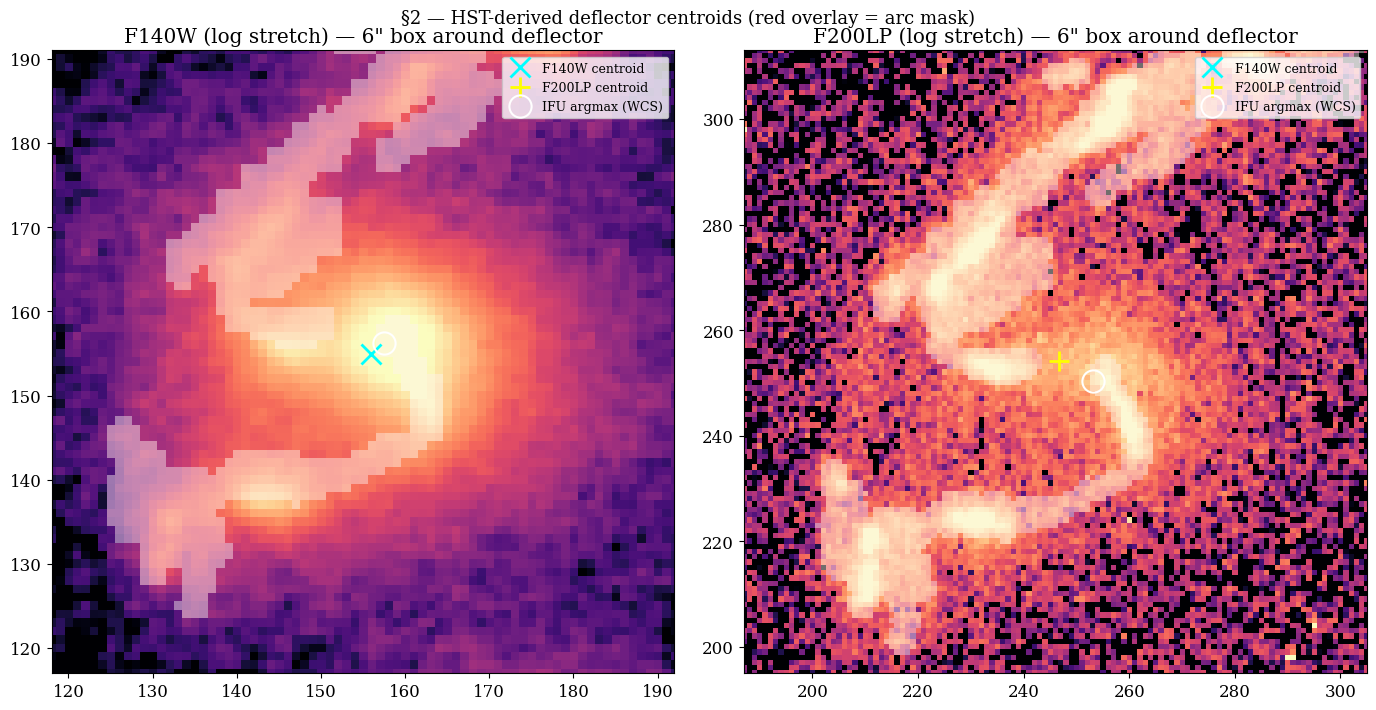

In [8]:
# Plot §2: F140W and F200LP with centroids marked
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, img, msk, xc, yc, pix_sc, ttl in [
    (axes[0], img_f140, mask_f140, xc_f140, yc_f140, pix_scale_f140, 'F140W'),
    (axes[1], img_f200, mask_f200, xc_f200, yc_f200, pix_scale_f200, 'F200LP'),
]:
    # show ~6" box
    half_pix = int(3.0 / pix_sc)
    y1, y2 = int(yc - half_pix), int(yc + half_pix)
    x1, x2 = int(xc - half_pix), int(xc + half_pix)
    sub = img[y1:y2, x1:x2]
    vmin = max(0, np.percentile(sub, 2))
    vmax = np.percentile(sub, 99)
    ax.imshow(np.log10(np.clip(img, 1e-3, None)),
              origin='lower', cmap='magma',
              vmin=np.log10(max(vmin, 1e-3)), vmax=np.log10(vmax))
    # mask overlay
    ax.imshow(np.where(msk, 1, np.nan), origin='lower', cmap='Reds', alpha=0.45)
    ax.plot(xc_f140, yc_f140, 'x', color='cyan', mew=2, ms=14, label='F140W centroid')
    ax.plot(xc_f200, yc_f200, '+', color='yellow', mew=2, ms=14, label='F200LP centroid')
    # WCS of IFU argmax
    ra_ifu_arg, dec_ifu_arg = wcs_ifu.pixel_to_world_values(cx_ifu_argmax, cy_ifu_argmax)
    x_wcs, y_wcs = (lambda w: w.world_to_pixel_values(ra_ifu_arg, dec_ifu_arg))({
        'F140W': wcs_f140, 'F200LP': wcs_f200}[ttl])
    ax.plot(x_wcs, y_wcs, 'o', mfc='none', mec='white', mew=1.5, ms=16, label='IFU argmax (WCS)')
    ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
    ax.set_title(f'{ttl} (log stretch) — 6\" box around deflector')
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('§2 — HST-derived deflector centroids (red overlay = arc mask)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s2_center.png'), dpi=150, bbox_inches='tight')
plt.show()

## §3. Measure R_e three ways

F140W (masked), F200LP (masked), IFU 6500-7500 Å white-light (unmasked). Curve-of-growth integrated annular-mean profile → R_e at 50% cumulative flux.

In [9]:
def curve_of_growth(image, center, pix_scale, mask=None,
                    r_max_arcsec=6.0, r_step_arcsec=0.1):
    """Annular-mean profile and curve of growth.
    Returns (r_mid, I_mean, cog, total, masked_frac).
    """
    xc, yc = center
    ny, nx = image.shape
    yy, xx = np.mgrid[:ny, :nx]
    r = np.hypot(xx - xc, yy - yc) * pix_scale  # arcsec
    r_edges = np.arange(0, r_max_arcsec + r_step_arcsec, r_step_arcsec)
    r_mid, I_mean, mfrac = [], [], []
    for j in range(len(r_edges) - 1):
        ann = (r >= r_edges[j]) & (r < r_edges[j+1])
        n_all = int(ann.sum())
        if n_all == 0:
            continue
        if mask is not None:
            good = ann & ~mask
            n_good = int(good.sum())
            mfrac.append(1 - n_good / n_all if n_all > 0 else 0)
        else:
            good = ann
            n_good = n_all
            mfrac.append(0.0)
        if n_good == 0:
            continue
        I_mean.append(float(np.mean(image[good])))
        r_mid.append(0.5 * (r_edges[j] + r_edges[j+1]))
    r_mid = np.array(r_mid); I_mean = np.array(I_mean); mfrac = np.array(mfrac)
    Re, cog, total = measure_Re_from_profile(r_mid, I_mean)
    return r_mid, I_mean, cog, total, mfrac, Re

In [10]:
# Measure Re three ways
cog_results = {}

r_f140, I_f140, cog_f140, tot_f140, mf_f140, Re_f140 = curve_of_growth(
    img_f140, (xc_f140, yc_f140), pix_scale_f140, mask=mask_f140,
    r_max_arcsec=6.0, r_step_arcsec=0.08)
cog_results['F140W_masked'] = dict(r=r_f140, I=I_f140, cog=cog_f140, total=tot_f140, mfrac=mf_f140, Re=Re_f140)
print(f'F140W masked     : Re = {Re_f140:.3f}\" = {Re_f140*KPC_PER_ARCSEC:.2f} kpc')

r_f200, I_f200, cog_f200, tot_f200, mf_f200, Re_f200 = curve_of_growth(
    img_f200, (xc_f200, yc_f200), pix_scale_f200, mask=mask_f200,
    r_max_arcsec=6.0, r_step_arcsec=0.08)
cog_results['F200LP_masked'] = dict(r=r_f200, I=I_f200, cog=cog_f200, total=tot_f200, mfrac=mf_f200, Re=Re_f200)
print(f'F200LP masked    : Re = {Re_f200:.3f}\" = {Re_f200*KPC_PER_ARCSEC:.2f} kpc')

r_ifu, I_ifu, cog_ifu, tot_ifu, mf_ifu, Re_ifu = curve_of_growth(
    ifu_band, (cx_ifu, cy_ifu), pix_scale_ifu, mask=None,
    r_max_arcsec=6.0, r_step_arcsec=0.3)
cog_results['IFU_band_unmasked'] = dict(r=r_ifu, I=I_ifu, cog=cog_ifu, total=tot_ifu, mfrac=mf_ifu, Re=Re_ifu)
print(f'IFU band unmasked: Re = {Re_ifu:.3f}\" = {Re_ifu*KPC_PER_ARCSEC:.2f} kpc')

# Headline Re: mean of the two HST (masked) values
R_E_HEADLINE = 0.5 * (Re_f140 + Re_f200)
print(f'\nHeadline Re (mean of F140W + F200LP masked): {R_E_HEADLINE:.3f}\" '
      f'= {R_E_HEADLINE*KPC_PER_ARCSEC:.2f} kpc')

F140W masked     : Re = 2.168" = 15.27 kpc
F200LP masked    : Re = 2.441" = 17.19 kpc
IFU band unmasked: Re = 2.299" = 16.19 kpc

Headline Re (mean of F140W + F200LP masked): 2.305" = 16.23 kpc


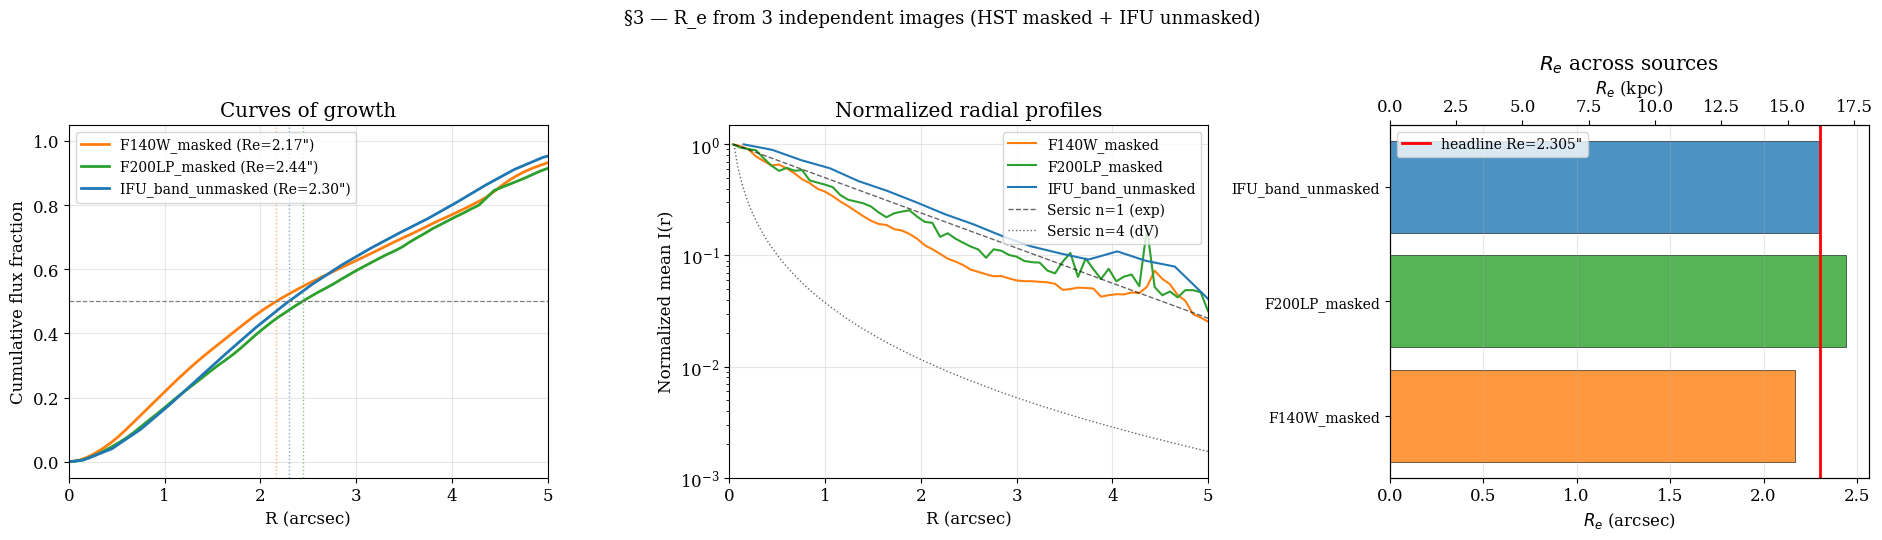

In [12]:
# §3 plots: CoG, profiles, bar chart
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (a) Curve of growth
colors = {'F140W_masked': 'C1', 'F200LP_masked': 'C2', 'IFU_band_unmasked': 'C0'}
for lbl, d in cog_results.items():
    if d['total'] <= 0: continue
    r_cog = np.concatenate([[0], d['r']])
    axes[0].plot(r_cog, d['cog'] / d['total'], lw=2, color=colors[lbl], label=f'{lbl} (Re={d["Re"]:.2f}\")')
    axes[0].axvline(d['Re'], color=colors[lbl], ls=':', lw=1.0, alpha=0.6)
axes[0].axhline(0.5, color='gray', ls='--', lw=0.9)
axes[0].set_xlabel('R (arcsec)'); axes[0].set_ylabel('Cumulative flux fraction')
axes[0].set_title('Curves of growth')
axes[0].set_xlim(0, 5); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=10)

# (b) Normalized radial profiles
for lbl, d in cog_results.items():
    if d['I'][0] <= 0: continue
    axes[1].plot(d['r'], d['I'] / d['I'][0], lw=1.5, color=colors[lbl], label=lbl)
# Sersic reference profiles (normalized at innermost radius)
from scipy.special import gammaincinv
def sersic_profile(r, Re, n):
    bn = gammaincinv(2*n, 0.5)
    return np.exp(-bn * ((r/Re)**(1/n) - 1))
r_ref = np.linspace(0.05, 5, 200)
axes[1].plot(r_ref, sersic_profile(r_ref, R_E_HEADLINE, 1) / sersic_profile(0.05, R_E_HEADLINE, 1),
             'k--', lw=1.0, alpha=0.6, label='Sersic n=1 (exp)')
axes[1].plot(r_ref, sersic_profile(r_ref, R_E_HEADLINE, 4) / sersic_profile(0.05, R_E_HEADLINE, 4),
             'k:', lw=1.0, alpha=0.6, label='Sersic n=4 (dV)')
axes[1].set_xlabel('R (arcsec)'); axes[1].set_ylabel('Normalized mean I(r)')
axes[1].set_yscale('log'); axes[1].set_xlim(0, 5); axes[1].set_ylim(1e-3, 1.5)
axes[1].set_title('Normalized radial profiles')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=10)

# (c) Bar chart of Re values
labels = list(cog_results.keys())
Re_vals = [cog_results[l]['Re'] for l in labels]
y = np.arange(len(labels))
bars = axes[2].barh(y, Re_vals, color=[colors[l] for l in labels], alpha=0.8,
                    edgecolor='black', lw=0.5)
# highlight mean-of-HST
axes[2].axvline(R_E_HEADLINE, color='red', ls='-', lw=2, label=f'headline Re={R_E_HEADLINE:.3f}\"')
axes[2].set_yticks(y); axes[2].set_yticklabels(labels, fontsize=10)
axes[2].set_xlabel(r'$R_e$ (arcsec)')
axes[2].set_title(r'$R_e$ across sources')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3, axis='x')
# kpc axis on top
ax2 = axes[2].twiny()
ax2.set_xlim(axes[2].get_xlim()[0]*KPC_PER_ARCSEC, axes[2].get_xlim()[1]*KPC_PER_ARCSEC)
ax2.set_xlabel(r'$R_e$ (kpc)')

fig.suptitle('§3 — R_e from 3 independent images (HST masked + IFU unmasked)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s3_Re.png'), dpi=150, bbox_inches='tight')
plt.show()

## §4. Define radial annuli

Five concentric annuli at [0, Re/8, Re/4, Re/2, 3Re/4, Re] on the IFU grid, centered on the HST-derived (cx, cy).

In [13]:
R_E = R_E_HEADLINE
r_edges = np.array([0.0, R_E/8, R_E/4, R_E/2, 3*R_E/4, R_E])
r_mid_ann = 0.5 * (r_edges[:-1] + r_edges[1:])
n_ann = len(r_edges) - 1

# Per-spaxel radial distance from HST-derived center on IFU grid
yy, xx = np.mgrid[:ny, :nx]
ra_s, dec_s = wcs_ifu.pixel_to_world_values(xx.ravel(), yy.ravel())
ra_c, dec_c = wcs_ifu.pixel_to_world_values(cx_ifu, cy_ifu)
dra = (ra_s.reshape(ny, nx) - ra_c) * np.cos(np.radians(dec_c)) * 3600
ddec = (dec_s.reshape(ny, nx) - dec_c) * 3600
r_spax = np.sqrt(dra**2 + ddec**2)

print(f'{ " ann":<4} {"r_lo":>8} {"r_hi":>8} {"r_mid":>8} {"kpc":>8} {"N_spax":>8}')
print('-' * 50)
ann_spax_counts = []
for j in range(n_ann):
    mask_ann = (r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])
    n_j = int(mask_ann.sum())
    ann_spax_counts.append(n_j)
    print(f'{j:>4d} {r_edges[j]:>8.3f} {r_edges[j+1]:>8.3f} {r_mid_ann[j]:>8.3f} '
          f'{r_mid_ann[j]*KPC_PER_ARCSEC:>8.2f} {n_j:>8d}')

 ann     r_lo     r_hi    r_mid      kpc   N_spax
--------------------------------------------------
   0    0.000    0.288    0.144     1.01        3
   1    0.288    0.576    0.432     3.04        8
   2    0.576    1.152    0.864     6.09       34
   3    1.152    1.728    1.440    10.14       59
   4    1.728    2.305    2.016    14.20       80


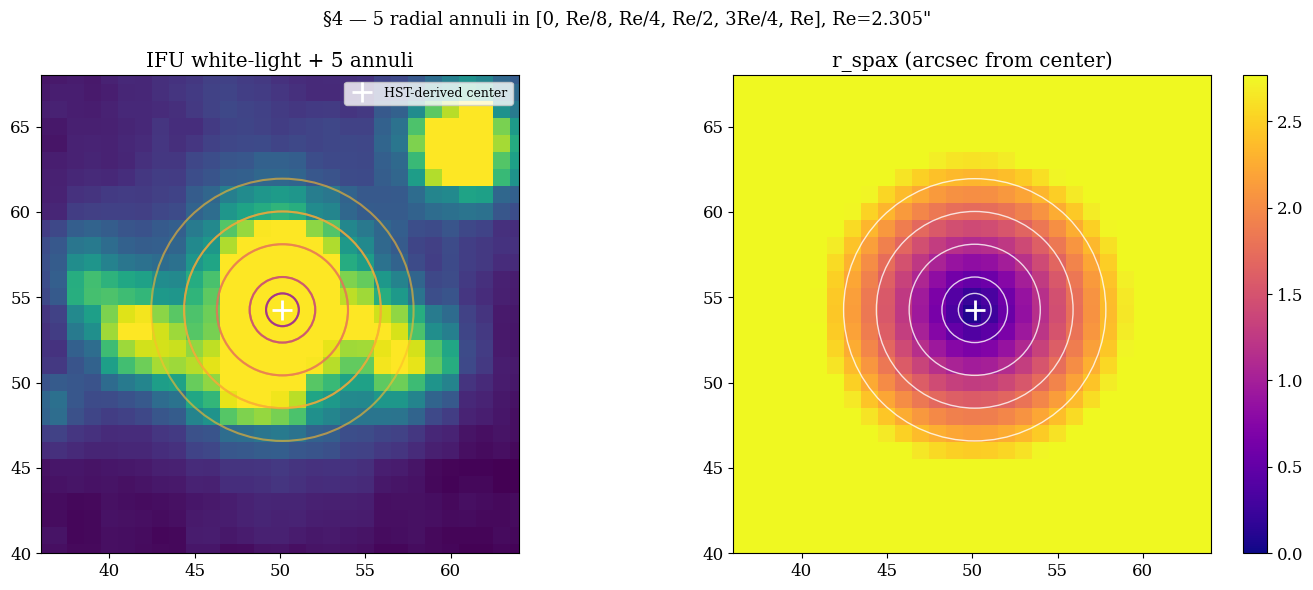

In [14]:
# §4 plot: annuli overlay on IFU white-light + r_spax heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Zoom window
delta = 14
y1 = max(0, int(cy_ifu - delta)); y2 = min(ny, int(cy_ifu + delta))
x1 = max(0, int(cx_ifu - delta)); x2 = min(nx, int(cx_ifu + delta))

# (a) IFU WL with annuli
axes[0].imshow(wl_full, origin='lower', cmap='viridis',
               extent=[-0.5, nx-0.5, -0.5, ny-0.5],
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[0].set_xlim(x1, x2); axes[0].set_ylim(y1, y2)
ann_colors = plt.cm.plasma(np.linspace(0.2, 0.85, n_ann))
for j in range(n_ann):
    for r_val, alpha_val in [(r_edges[j], 0.6), (r_edges[j+1], 0.6)]:
        axes[0].add_patch(Circle((cx_ifu, cy_ifu), r_val/pix_scale_ifu,
                                  fill=False, edgecolor=ann_colors[j],
                                  lw=1.5, alpha=alpha_val))
axes[0].plot(cx_ifu, cy_ifu, 'w+', ms=14, mew=2, label='HST-derived center')
axes[0].set_title('IFU white-light + 5 annuli')
axes[0].legend(fontsize=9)

# (b) r_spax heatmap
im = axes[1].imshow(r_spax, origin='lower', cmap='plasma', vmin=0, vmax=R_E*1.2,
                    extent=[-0.5, nx-0.5, -0.5, ny-0.5])
axes[1].set_xlim(x1, x2); axes[1].set_ylim(y1, y2)
for j in range(n_ann):
    axes[1].add_patch(Circle((cx_ifu, cy_ifu), r_edges[j+1]/pix_scale_ifu,
                              fill=False, edgecolor='white', lw=1.0, alpha=0.8))
axes[1].plot(cx_ifu, cy_ifu, 'w+', ms=14, mew=2)
axes[1].set_title('r_spax (arcsec from center)')
plt.colorbar(im, ax=axes[1], fraction=0.046)

fig.suptitle(f'§4 — 5 radial annuli in [0, Re/8, Re/4, Re/2, 3Re/4, Re], Re={R_E:.3f}\"',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s4_annuli.png'), dpi=150, bbox_inches='tight')
plt.show()

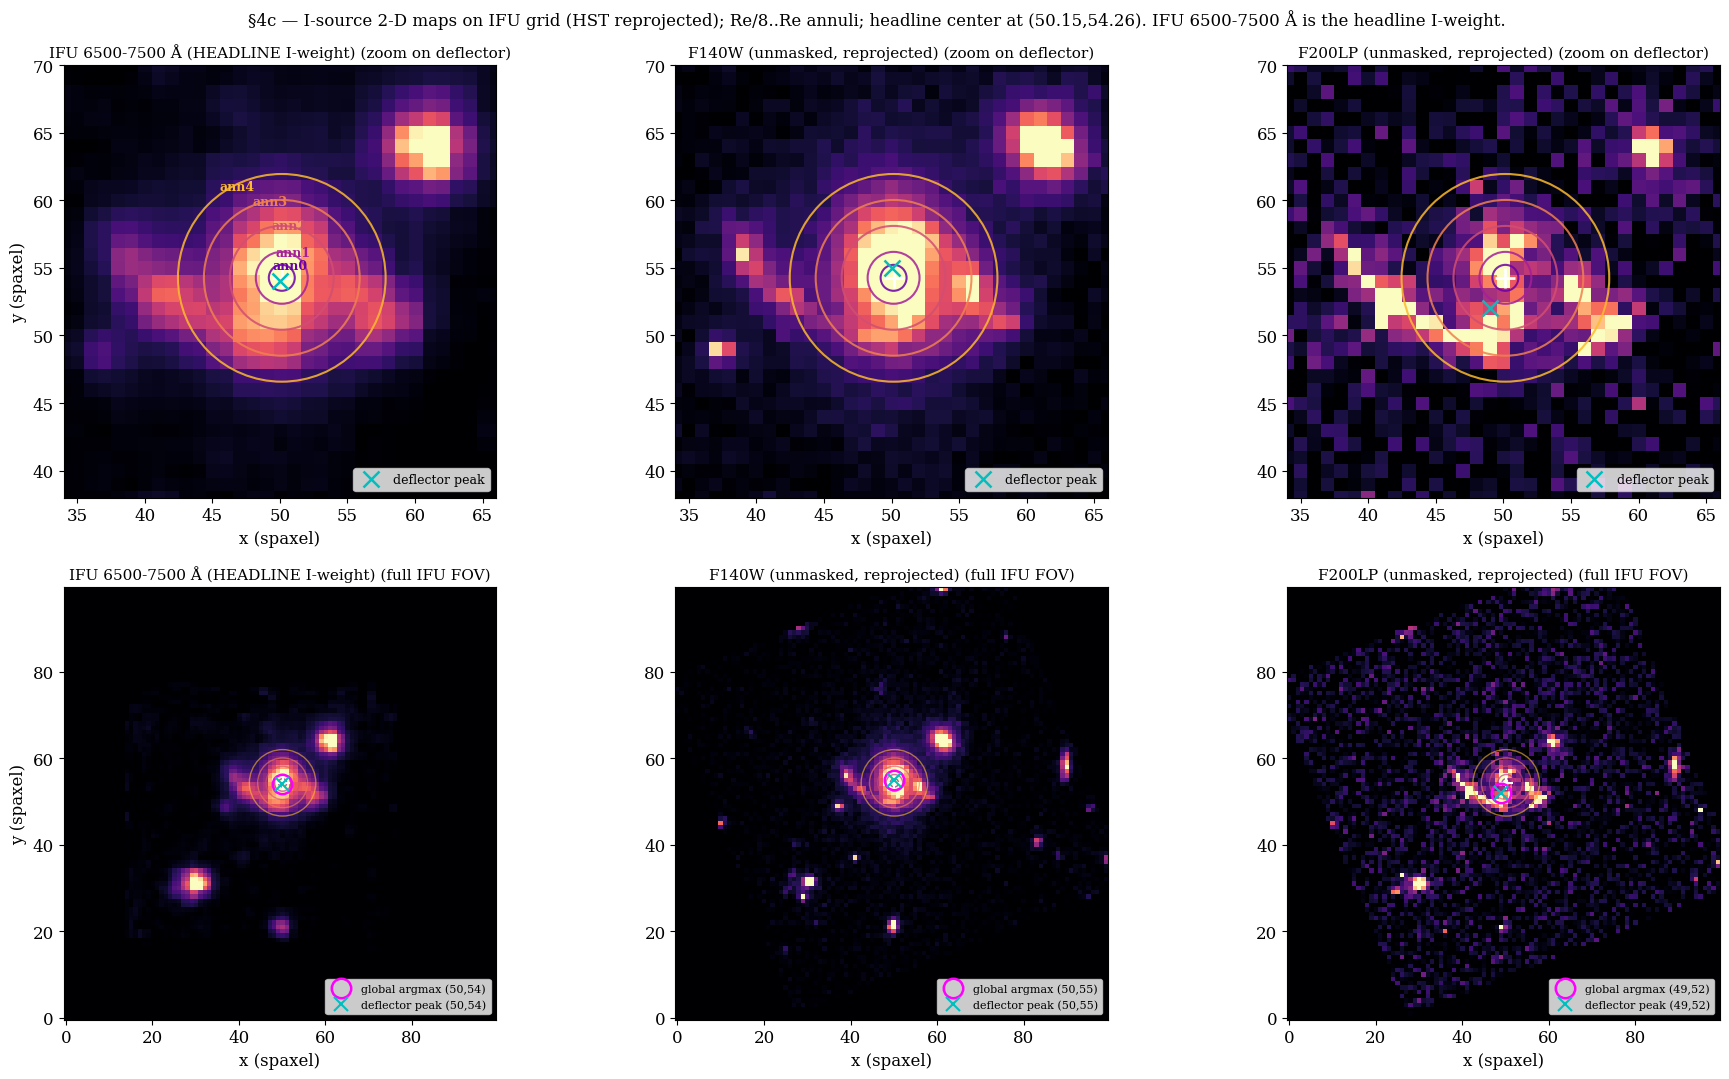

IFU 6500-7500 Å band 2D map:
  shape (100, 100), sum 4.439e+03
  deflector-near peak (smoothed, sigma=3): IFU pixel (50,54)
  GLOBAL peak (smoothed): IFU pixel (50,54) [if far from deflector, likely a companion/sky-residual in the IFU FOV]
  deflector-peak offset from chosen center: 0.091"
  percentile values: p50=0.000, p99=10.916, max=33.818


In [15]:
# §4c — Three I-source 2D maps on the IFU grid, with annuli overlaid.
# This is the plot the user asks about: where is the 6500-7500 Å band image?
# It's the HEADLINE I(r) weight for the Gültekin integral.

def _reproject_to_ifu(img_hst, wcs_hst_, ny_=ny, nx_=nx, wcs_ifu_=wcs_ifu):
    yyq, xxq = np.mgrid[:ny_, :nx_]
    ra_q, dec_q = wcs_ifu_.pixel_to_world_values(xxq.ravel(), yyq.ravel())
    xh, yh = wcs_hst_.world_to_pixel_values(ra_q, dec_q)
    I = map_coordinates(np.nan_to_num(img_hst), [yh, xh],
                        order=1, mode='constant', cval=0.0).reshape(ny_, nx_)
    return np.clip(I, 0, None)

img_panels = [
    ('IFU 6500-7500 Å (HEADLINE I-weight)', ifu_band, 'magma'),
    ('F140W (unmasked, reprojected)', _reproject_to_ifu(img_f140, wcs_f140), 'magma'),
    ('F200LP (unmasked, reprojected)', _reproject_to_ifu(img_f200, wcs_f200), 'magma'),
]

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
delta_z = 16
y1 = max(0, int(cy_ifu - delta_z)); y2 = min(ny, int(cy_ifu + delta_z))
x1 = max(0, int(cx_ifu - delta_z)); x2 = min(nx, int(cx_ifu + delta_z))
ann_cols = plt.cm.plasma(np.linspace(0.2, 0.85, n_ann))
from scipy.ndimage import gaussian_filter as _gf

for col, (title, img, cmap) in enumerate(img_panels):
    pos = img[img > 0]
    vmax = np.percentile(pos, 99) if len(pos) else 1
    # Smoothed deflector-region peak (use a larger sigma so noise spikes don't win)
    img_smooth = _gf(img, sigma=3.0)
    # find peak near the deflector (within 5 spaxels)
    mask_near = np.hypot(np.arange(nx)[None,:] - cx_ifu,
                         np.arange(ny)[:,None] - cy_ifu) <= 8.0
    img_for_peak = np.where(mask_near, img_smooth, -np.inf)
    ypk, xpk = np.unravel_index(np.argmax(img_for_peak), img.shape)
    # Global argmax (including any off-deflector bright source)
    ypk_g, xpk_g = np.unravel_index(np.argmax(img_smooth), img.shape)

    # Row 0 — ZOOMED on deflector
    ax = axes[0, col]
    ax.imshow(img, origin='lower', cmap=cmap, extent=[-0.5, nx-0.5, -0.5, ny-0.5],
              vmin=0, vmax=vmax)
    for j in range(n_ann):
        ax.add_patch(Circle((cx_ifu, cy_ifu), r_edges[j+1]/pix_scale_ifu,
                            fill=False, edgecolor=ann_cols[j], lw=1.5, alpha=0.85))
    ax.plot(cx_ifu, cy_ifu, 'w+', ms=14, mew=2)
    ax.plot(xpk, ypk, 'cx', ms=12, mew=1.8, label='deflector peak')
    ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
    ax.set_title(f'{title} (zoom on deflector)', fontsize=11)
    ax.set_xlabel('x (spaxel)')
    ax.legend(fontsize=9, loc='lower right')
    if col == 0: ax.set_ylabel('y (spaxel)')

    # Row 1 — FULL FOV
    ax = axes[1, col]
    ax.imshow(img, origin='lower', cmap=cmap, extent=[-0.5, nx-0.5, -0.5, ny-0.5],
              vmin=0, vmax=vmax)
    for j in range(n_ann):
        ax.add_patch(Circle((cx_ifu, cy_ifu), r_edges[j+1]/pix_scale_ifu,
                            fill=False, edgecolor=ann_cols[j], lw=1.0, alpha=0.6))
    ax.plot(cx_ifu, cy_ifu, 'w+', ms=10, mew=1.5)
    # Mark the global argmax to expose any off-deflector bright source
    ax.plot(xpk_g, ypk_g, 'o', color='magenta', mfc='none', mec='magenta',
            mew=1.8, ms=14, label=f'global argmax ({xpk_g},{ypk_g})')
    # Mark deflector peak in cyan
    ax.plot(xpk, ypk, 'cx', ms=10, mew=1.5, label=f'deflector peak ({xpk},{ypk})')
    ax.set_xlim(-0.5, nx-0.5); ax.set_ylim(-0.5, ny-0.5)
    ax.set_title(f'{title} (full IFU FOV)', fontsize=11)
    ax.set_xlabel('x (spaxel)')
    ax.legend(fontsize=8, loc='lower right')
    if col == 0: ax.set_ylabel('y (spaxel)')

# Label annuli on the first zoom panel
for j in range(n_ann):
    theta = np.radians(45 + 18*j)
    rx = (r_edges[j+1]/pix_scale_ifu) * 0.95
    txt_x = cx_ifu + rx * np.cos(theta)
    txt_y = cy_ifu + rx * np.sin(theta)
    axes[0, 0].annotate(f'ann{j}', (txt_x, txt_y), color=ann_cols[j],
                     fontsize=9, ha='center', fontweight='bold')

fig.suptitle(f'§4c — I-source 2-D maps on IFU grid (HST reprojected); Re/8..Re annuli; '
             f'headline center at ({cx_ifu:.2f},{cy_ifu:.2f}). '
             f'IFU 6500-7500 Å is the headline I-weight.',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s4c_Imaps.png'), dpi=160, bbox_inches='tight')
plt.show()

# Also print the 2D IFU_band image summary so the user can see the numerical content
print(f'IFU 6500-7500 Å band 2D map:')
print(f'  shape {ifu_band.shape}, sum {ifu_band.sum():.3e}')
# Recompute deflector-near peak for IFU_band (near the chosen center, sigma=3)
ifu_band_smooth = gaussian_filter(ifu_band, sigma=3.0)
_near = np.hypot(np.arange(nx)[None,:] - cx_ifu, np.arange(ny)[:,None] - cy_ifu) <= 8.0
_y_def, _x_def = np.unravel_index(np.argmax(np.where(_near, ifu_band_smooth, -np.inf)), ifu_band.shape)
_y_glob, _x_glob = np.unravel_index(np.argmax(ifu_band_smooth), ifu_band.shape)
print(f'  deflector-near peak (smoothed, sigma=3): IFU pixel ({_x_def},{_y_def})')
print(f'  GLOBAL peak (smoothed): IFU pixel ({_x_glob},{_y_glob}) '
      f'[if far from deflector, likely a companion/sky-residual in the IFU FOV]')
print(f'  deflector-peak offset from chosen center: '
      f'{np.hypot(_x_def-cx_ifu, _y_def-cy_ifu)*pix_scale_ifu:.3f}\"')
print(f'  percentile values: p50={np.percentile(ifu_band,50):.3f}, '
      f'p99={np.percentile(ifu_band,99):.3f}, max={ifu_band.max():.3f}')

Ca K: line 6585-6597 Å, cont 6515-6555 Å   peak-depth at IFU pixel (np.int64(56), np.int64(49))   (value 0.017)
Ca H: line 6644-6656 Å, cont 6680-6720 Å   peak-depth at IFU pixel (np.int64(55), np.int64(50))   (value 0.014)
G-band: line 7206-7220 Å, cont 7110-7170 Å   peak-depth at IFU pixel (np.int64(55), np.int64(50))   (value 0.014)

Combined I_defline: sum=1.022e+01, max=0.035


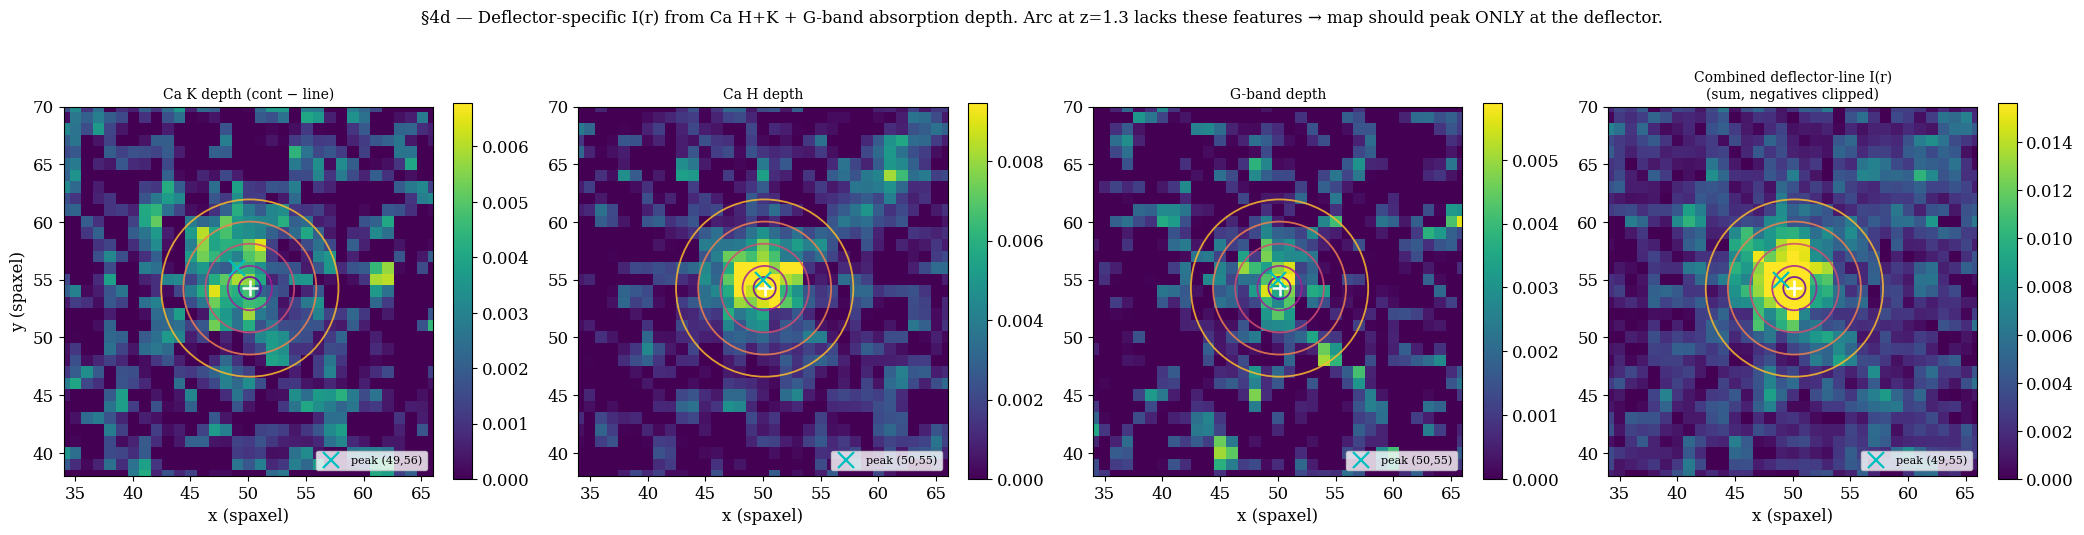


Deflector-line I per annulus:
  ann0 R=0.14" : I_defline=5.929e-02  I_band=6.539e+01  ratio=0.001
  ann1 R=0.43" : I_defline=1.404e-01  I_band=1.579e+02  ratio=0.001
  ann2 R=0.86" : I_defline=4.038e-01  I_band=5.065e+02  ratio=0.001
  ann3 R=1.44" : I_defline=3.710e-01  I_band=5.688e+02  ratio=0.001
  ann4 R=2.02" : I_defline=3.164e-01  I_band=5.113e+02  ratio=0.001


In [16]:
# §4d — Deflector-specific I(r) from Ca H+K + G-band ABSORPTION DEPTH.
#
# Hypothesis: at z=0.67564, the deflector's Ca H+K (rest 3933.66, 3968.47 Å)
# and G-band (4304.40 Å) land at observed ~6590, ~6650, ~7211 Å. The lensed arc
# at z=1.302 contributes only featureless rest-UV (~2850-3130 Å) at those same
# observed wavelengths, so it does NOT show these absorption features. An I(r)
# built from the depth of the absorption (continuum - line) should isolate
# the deflector's stellar light much more cleanly than the broadband band-pass.

# Line windows (observed, z=0.67564)
LINE_WIN = {
    'Ca K':   (3933.66*(1+Z_SYSTEMIC) - 6.0, 3933.66*(1+Z_SYSTEMIC) + 6.0),  # ~6584-6596 Å
    'Ca H':   (3968.47*(1+Z_SYSTEMIC) - 6.0, 3968.47*(1+Z_SYSTEMIC) + 6.0),  # ~6642-6654 Å
    'G-band': (4304.40*(1+Z_SYSTEMIC) - 7.0, 4304.40*(1+Z_SYSTEMIC) + 7.0),  # ~7204-7218 Å
}
# Continuum windows (deliberately offset from absorption features)
CONT_WIN = {
    'Ca K':   (6515, 6555),   # blueward of Ca K
    'Ca H':   (6680, 6720),   # redward of Ca H / blueward of H-delta at ~6872
    'G-band': (7110, 7170),   # blueward of G-band
}

def line_depth_map(cube, lam, line_lo, line_hi, cont_lo, cont_hi):
    """Per-spaxel absorption depth = median(continuum_band) - median(line_band).
    Positive where absorption is present; near zero for featureless continuum."""
    line_mask = (lam >= line_lo) & (lam <= line_hi)
    cont_mask = (lam >= cont_lo) & (lam <= cont_hi)
    if not line_mask.any() or not cont_mask.any():
        return np.zeros((cube.shape[1], cube.shape[2]))
    line_flux = np.nanmedian(cube[line_mask, :, :], axis=0)
    cont_flux = np.nanmedian(cube[cont_mask, :, :], axis=0)
    return cont_flux - line_flux   # absorption depth (positive = absorbed)

depth_CaK = line_depth_map(cube, lam, *LINE_WIN['Ca K'], *CONT_WIN['Ca K'])
depth_CaH = line_depth_map(cube, lam, *LINE_WIN['Ca H'], *CONT_WIN['Ca H'])
depth_G   = line_depth_map(cube, lam, *LINE_WIN['G-band'], *CONT_WIN['G-band'])

# Combined deflector-line I map: clip negatives (continuum > line is absorption;
# noise can push this negative for non-deflector spaxels)
I_defline = np.clip(depth_CaK, 0, None) + np.clip(depth_CaH, 0, None) + np.clip(depth_G, 0, None)

# Print summary
for name, lw, cw, dm in [
    ('Ca K', LINE_WIN['Ca K'], CONT_WIN['Ca K'], depth_CaK),
    ('Ca H', LINE_WIN['Ca H'], CONT_WIN['Ca H'], depth_CaH),
    ('G-band', LINE_WIN['G-band'], CONT_WIN['G-band'], depth_G),
]:
    print(f'{name}: line {lw[0]:.0f}-{lw[1]:.0f} Å, cont {cw[0]}-{cw[1]} Å   '
          f'peak-depth at IFU pixel '
          f'{np.unravel_index(np.argmax(gaussian_filter(dm, sigma=2)), dm.shape)}   '
          f'(value {dm.max():.3f})')
print(f'\nCombined I_defline: sum={I_defline.sum():.3e}, '
      f'max={I_defline.max():.3f}')

# Visualize: 4-panel comparison
fig, axes = plt.subplots(1, 4, figsize=(21, 5.5))
delta_z = 16
y1 = max(0, int(cy_ifu - delta_z)); y2 = min(ny, int(cy_ifu + delta_z))
x1 = max(0, int(cx_ifu - delta_z)); x2 = min(nx, int(cx_ifu + delta_z))
ann_cols = plt.cm.plasma(np.linspace(0.2, 0.85, n_ann))

panels = [
    ('Ca K depth (cont − line)', depth_CaK),
    ('Ca H depth', depth_CaH),
    ('G-band depth', depth_G),
    ('Combined deflector-line I(r)\n(sum, negatives clipped)', I_defline),
]
for ax, (ttl, im2d) in zip(axes, panels):
    pos = im2d[im2d > 0]
    vmax = np.percentile(pos, 99) if len(pos) else 1.0
    im = ax.imshow(im2d, origin='lower', cmap='viridis',
                   extent=[-0.5, nx-0.5, -0.5, ny-0.5],
                   vmin=0, vmax=vmax)
    # overlay annuli
    for j in range(n_ann):
        ax.add_patch(Circle((cx_ifu, cy_ifu), r_edges[j+1]/pix_scale_ifu,
                            fill=False, edgecolor=ann_cols[j], lw=1.3, alpha=0.85))
    ax.plot(cx_ifu, cy_ifu, 'w+', ms=12, mew=1.8)
    # argmax (smoothed) — should be AT the deflector if the line is truly deflector-specific
    ypk, xpk = np.unravel_index(np.argmax(gaussian_filter(im2d, sigma=2)), im2d.shape)
    ax.plot(xpk, ypk, 'cx', ms=12, mew=1.6, label=f'peak ({xpk},{ypk})')
    ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
    ax.set_title(ttl, fontsize=10)
    ax.set_xlabel('x (spaxel)')
    ax.legend(fontsize=8, loc='lower right')
    plt.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel('y (spaxel)')

fig.suptitle(f'§4d — Deflector-specific I(r) from Ca H+K + G-band absorption depth. '
             f'Arc at z=1.3 lacks these features → map should peak ONLY at the deflector.',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s4d_line_depth.png'), dpi=160, bbox_inches='tight')
plt.show()

# Also print per-annulus totals for this new I-source
print(f'\nDeflector-line I per annulus:')
for j in range(n_ann):
    ann_mask = (r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])
    F_def = I_defline[ann_mask].sum()
    F_band = ifu_band[ann_mask].sum()
    print(f'  ann{j} R={r_mid_ann[j]:.2f}\" : '
          f'I_defline={F_def:.3e}  I_band={F_band:.3e}  '
          f'ratio={F_def/F_band:.3f}')

## §5. Extract per-annulus spectra

For each annulus: contamination-weighted spatial average of the cube. Weights = `1 − spaxel_contam` (derived from the F140W arc mask convolved with KCWI seeing PSF and reprojected onto the IFU grid). Arc-contaminated spaxels are down-weighted, not excluded.

In [17]:
# Build the per-spaxel arc contamination map (arc region only, from F140W mask)
# This is the SAME construction as 05x cell 24-25. Mask is convolved with the
# KCWI seeing PSF (so the effective arc contamination on any IFU spaxel reflects
# how much arc light "smears" onto it via the atmosphere), then reprojected onto
# the IFU grid.
psf_sigma_hst_pix = (KCWI_SEEING_FWHM / HST_PIXSCALE_F140W) / 2.355
mask_convolved = gaussian_filter(mask_f140.astype(float), sigma=psf_sigma_hst_pix)
# Reproject to IFU grid using the same WCS machinery
_yy, _xx = np.mgrid[0:ny, 0:nx]
_ra, _dec = wcs_ifu.pixel_to_world_values(_xx.ravel(), _yy.ravel())
_xh, _yh = wcs_f140.world_to_pixel_values(_ra, _dec)
spaxel_contam = map_coordinates(mask_convolved, [_yh, _xh],
                                order=1, mode='constant', cval=0.0).reshape(ny, nx)
print(f'Spaxel contamination map: max={spaxel_contam.max():.3f}, '
      f'spaxels > {CONTAM_THRESHOLD} = {(spaxel_contam > CONTAM_THRESHOLD).sum()}')

# Noise per wavelength channel from a sky sub-region
noise_sky = np.std(cube[:, NOISE_SLICE[0], NOISE_SLICE[1]], axis=(1, 2))
print(f'Noise sky std: median={np.median(noise_sky):.3f}, '
      f'in 6500-7500 Å band = {np.median(noise_sky[band_mask]):.3f}')

Spaxel contamination map: max=0.617, spaxels > 0.15 = 198
Noise sky std: median=0.003, in 6500-7500 Å band = 0.003


In [18]:
# Extract each annulus's contamination-weighted integrated spectrum
annular_spectra = []  # list of dicts: {r_lo, r_hi, r_mid, flux, noise, n_spax, mean_weight, sn_band}
for j in range(n_ann):
    ann_mask = (r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])
    n_j = int(ann_mask.sum())
    if n_j < 1:
        print(f'Annulus {j}: N_spax=0, SKIPPING'); continue
    weights = np.clip(1.0 - spaxel_contam[ann_mask], 0.01, 1.0)
    flux = np.average(cube[:, ann_mask], axis=1, weights=weights)
    sn_band = np.median(flux[band_mask]) / np.median(noise_sky[band_mask])
    annular_spectra.append({
        'r_lo': r_edges[j], 'r_hi': r_edges[j+1], 'r_mid': r_mid_ann[j],
        'flux': flux, 'noise': noise_sky.copy(),
        'n_spax': n_j, 'mean_weight': float(weights.mean()),
        'sn_band': float(sn_band),
    })
    print(f'Annulus {j}: R={r_edges[j]:.2f}-{r_edges[j+1]:.2f}\" '
          f'N={n_j:3d} mean_weight={weights.mean():.3f} S/N_band={sn_band:.1f}')

Annulus 0: R=0.00-0.29" N=  3 mean_weight=0.742 S/N_band=7.2
Annulus 1: R=0.29-0.58" N=  8 mean_weight=0.727 S/N_band=6.6
Annulus 2: R=0.58-1.15" N= 34 mean_weight=0.736 S/N_band=5.0
Annulus 3: R=1.15-1.73" N= 59 mean_weight=0.742 S/N_band=3.1
Annulus 4: R=1.73-2.30" N= 80 mean_weight=0.790 S/N_band=1.9


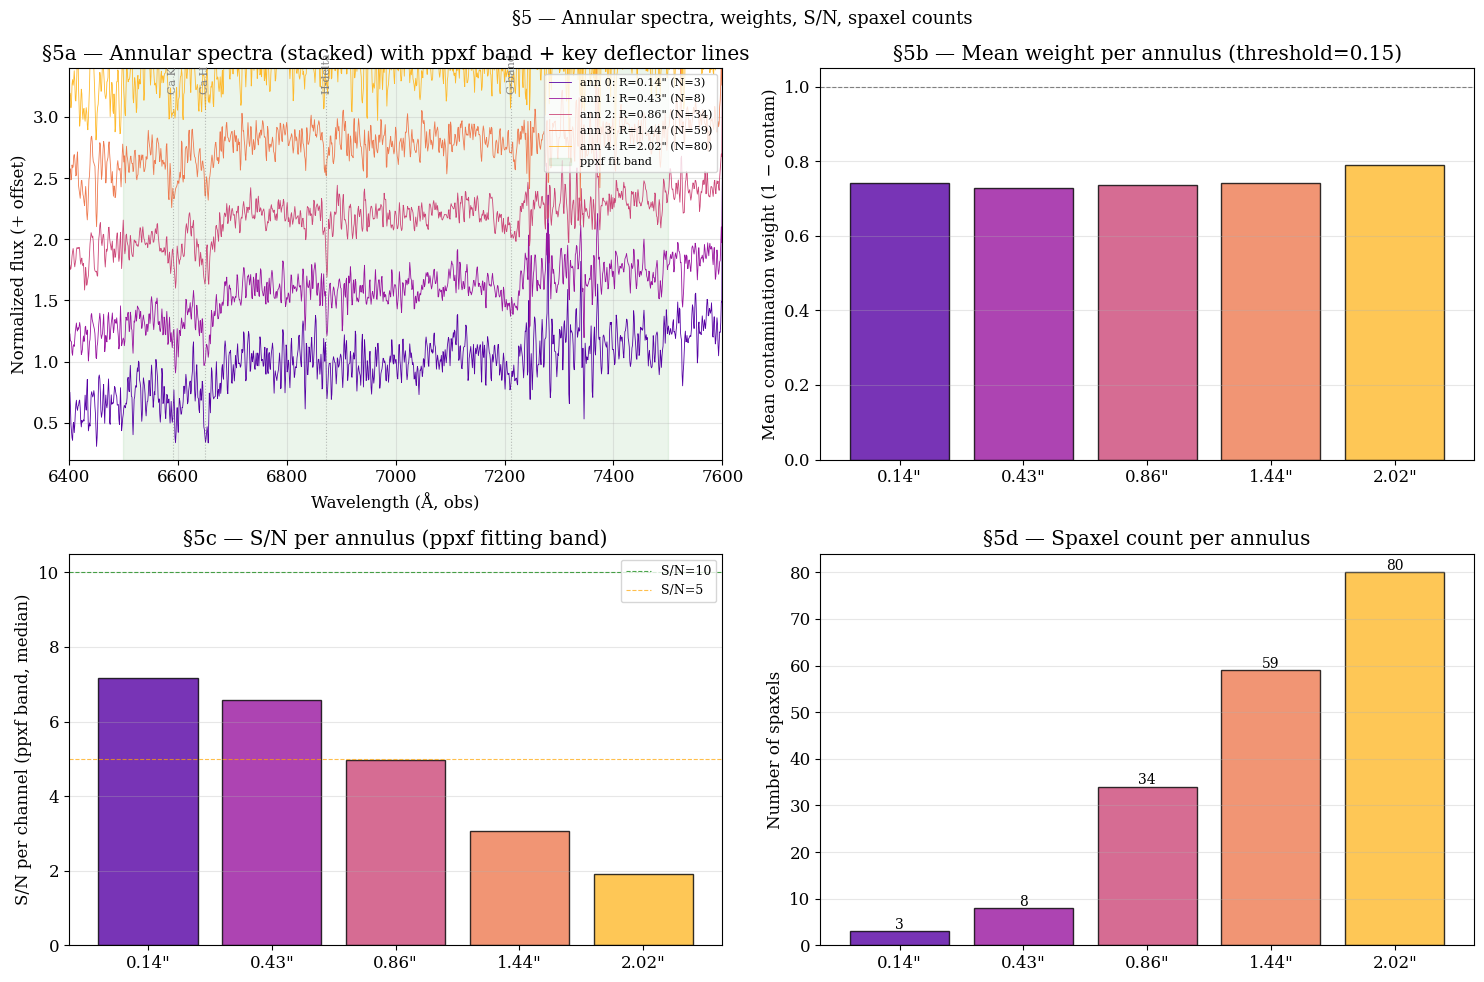

In [19]:
# Plot §5a-c: annular spectra, mean weights, S/N bar chart
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) Annular spectra stacked, zoomed on ppxf band
ax = axes[0, 0]
rest_lines = {'Ca K': 3933.66, 'Ca H': 3968.47, 'H-delta': 4101.74, 'G-band': 4304.40}
offsets = np.arange(len(annular_spectra)) * 0.6
cmap = plt.cm.plasma(np.linspace(0.15, 0.85, len(annular_spectra)))
for j, (s, off, c) in enumerate(zip(annular_spectra, offsets, cmap)):
    norm = s['flux'] / np.median(s['flux'][band_mask])
    ax.plot(lam, norm + off, lw=0.6, color=c,
            label=f'ann {j}: R={s["r_mid"]:.2f}\" (N={s["n_spax"]})')
# Mark ppxf band
ax.axvspan(6500, 7500, color='green', alpha=0.08, label='ppxf fit band')
# Line annotations (observed frame)
for lname, l_rest in rest_lines.items():
    l_obs = l_rest * (1 + Z_SYSTEMIC)
    if 6000 < l_obs < 8000:
        ax.axvline(l_obs, color='gray', ls=':', lw=0.8, alpha=0.5)
        ax.text(l_obs, offsets[-1]+0.8, lname, fontsize=8, ha='center',
                color='gray', rotation=90)
ax.set_xlim(6400, 7600); ax.set_ylim(0.2, offsets[-1]+1.0)
ax.set_xlabel('Wavelength (Å, obs)'); ax.set_ylabel('Normalized flux (+ offset)')
ax.set_title('§5a — Annular spectra (stacked) with ppxf band + key deflector lines')
ax.legend(fontsize=8, loc='upper right', ncol=1)
ax.grid(alpha=0.3)

# (b) Mean weight per annulus
ax = axes[0, 1]
r_mids = [s['r_mid'] for s in annular_spectra]
weights = [s['mean_weight'] for s in annular_spectra]
ax.bar(range(len(annular_spectra)), weights, color=cmap, alpha=0.8, edgecolor='black')
ax.set_xticks(range(len(annular_spectra)))
ax.set_xticklabels([f'{r:.2f}\"' for r in r_mids])
ax.set_ylabel('Mean contamination weight (1 − contam)')
ax.set_ylim(0, 1.05)
ax.set_title(f'§5b — Mean weight per annulus (threshold={CONTAM_THRESHOLD})')
ax.axhline(1.0, color='gray', ls='--', lw=0.8)
ax.grid(alpha=0.3, axis='y')

# (c) S/N per annulus
ax = axes[1, 0]
sn_vals = [s['sn_band'] for s in annular_spectra]
ax.bar(range(len(annular_spectra)), sn_vals, color=cmap, alpha=0.8, edgecolor='black')
ax.set_xticks(range(len(annular_spectra)))
ax.set_xticklabels([f'{r:.2f}\"' for r in r_mids])
ax.set_ylabel('S/N per channel (ppxf band, median)')
ax.set_title('§5c — S/N per annulus (ppxf fitting band)')
ax.axhline(10, color='green', ls='--', lw=0.8, alpha=0.7, label='S/N=10')
ax.axhline(5, color='orange', ls='--', lw=0.8, alpha=0.7, label='S/N=5')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# (d) Spaxel count per annulus
ax = axes[1, 1]
n_vals = [s['n_spax'] for s in annular_spectra]
ax.bar(range(len(annular_spectra)), n_vals, color=cmap, alpha=0.8, edgecolor='black')
ax.set_xticks(range(len(annular_spectra)))
ax.set_xticklabels([f'{r:.2f}\"' for r in r_mids])
ax.set_ylabel('Number of spaxels')
ax.set_title('§5d — Spaxel count per annulus')
for i, v in enumerate(n_vals):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)
ax.grid(alpha=0.3, axis='y')

fig.suptitle('§5 — Annular spectra, weights, S/N, spaxel counts', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s5_annular_spectra.png'), dpi=150, bbox_inches='tight')
plt.show()

## §6. Per-SPS bootstrap ppxf per annulus

For each (annulus, SPS ∈ {FSPS, EMILES, XSL}):
1. Set up ppxf inputs using `setup_ppxf_inputs_from_spectrum`.
2. Run ppxf at each polynomial degree in `DEGREES` to get `best_fit[deg]`.
3. Run wild bootstrap via `run_bootstrap_single_degree` at each degree with N=`N_BOOTSTRAP`.
4. Save V and σ posterior arrays of shape `(n_deg, n_bootstrap)`.

z_systemic = 0.67564 for all fits. Per-SPS V_offset computed in §7.

Smoke: 15 fits × 10 bootstraps × 6 degrees ≈ 3 min. Full: 15 fits × 500 × 15 ≈ 1.5 h.

In [20]:
# Per-annulus, per-SPS ppxf bootstrap
# Results are stored as bootstrap_results[(j, sps)] and saved to ANNULAR_DIR
# FAST-PATH: if all annulus/SPS .npz files already exist on disk, RELOAD them
# instead of re-running the ~1h bootstrap. Delete the files to force a fresh run.
bootstrap_results = {}
_all_files_exist = all(
    os.path.exists(os.path.join(ANNULAR_DIR, f'ann{j}_{sps}.npz'))
    for j in range(len(annular_spectra)) for sps in SPS_LIBS
)
if _all_files_exist:
    print(f'FAST-PATH: reloading bootstrap_results from {ANNULAR_DIR} ...')
    for j, s in enumerate(annular_spectra):
        for sps in SPS_LIBS:
            d = dict(np.load(os.path.join(ANNULAR_DIR, f'ann{j}_{sps}.npz'), allow_pickle=True))
            # Scalar fields from npz come as 0-d arrays; unwrap
            for k in list(d.keys()):
                if d[k].shape == ():
                    d[k] = d[k].item()
            bootstrap_results[(j, sps)] = d
            print(f'  loaded ann{j} ({s["r_mid"]:.2f}\") / {sps}: '
                  f'σ range {d["sig_orig"].min():.0f}-{d["sig_orig"].max():.0f}')
    print('FAST-PATH DONE. Skipping bootstrap re-run.')

else:
    t_total = clock()
    for j, s in enumerate(annular_spectra):
        for sps in SPS_LIBS:
            key = (j, sps)
            t0 = clock()
            inputs = setup_ppxf_inputs_from_spectrum(
                s['flux'], s['noise'], hdr, sps_name=sps, z=Z_SYSTEMIC, verbose=False)
            n_pix = len(inputs['galaxy']); n_deg = len(DEGREES)
            best_fit = np.zeros((n_deg, n_pix))
            V_orig = np.zeros(n_deg); sig_orig = np.zeros(n_deg); chi2_orig = np.zeros(n_deg)
            V_boot = np.full((n_deg, N_BOOTSTRAP), np.nan)
            sig_boot = np.full((n_deg, N_BOOTSTRAP), np.nan)
            chi2_boot = np.full((n_deg, N_BOOTSTRAP), np.nan)
            for i, deg in enumerate(DEGREES):
                pp = ppxf(inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
                         inputs['velscale'], inputs['start'],
                         goodpixels=inputs['goodpixels'], plot=False, moments=2,
                         trig=False, degree=int(deg), mdegree=0,
                         lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=True)
                best_fit[i] = pp.bestfit
                V_orig[i] = pp.sol[0]; sig_orig[i] = pp.sol[1]; chi2_orig[i] = pp.chi2
                rb = run_bootstrap_single_degree(
                    inputs, degree=int(deg), best_fit_spectrum=pp.bestfit,
                    n_bootstrap=N_BOOTSTRAP, window=WINDOW, seed=BOOT_SEED + 100*j + i)
                V_boot[i] = rb['V_samples']; sig_boot[i] = rb['sigma_samples']; chi2_boot[i] = rb['chi2_samples']
            bootstrap_results[key] = {
                'V_orig': V_orig, 'sig_orig': sig_orig, 'chi2_orig': chi2_orig,
                'V_boot': V_boot, 'sig_boot': sig_boot, 'chi2_boot': chi2_boot,
                'best_fit': best_fit,
                'galaxy': inputs['galaxy'], 'noise': inputs['noise'],
                'lam_gal_rest': inputs['lam_gal_rest'],
                'goodpixels': inputs['goodpixels'], 'degrees': np.asarray(DEGREES),
                'z_input': Z_SYSTEMIC, 'r_mid': s['r_mid'], 'r_lo': s['r_lo'], 'r_hi': s['r_hi'], 'sps': sps,
            }
            np.savez(os.path.join(ANNULAR_DIR, f'ann{j}_{sps}.npz'),
                     **{k: v for k, v in bootstrap_results[key].items() if k != 'goodpixels'},
                     goodpixels=bootstrap_results[key]['goodpixels'])
            print(f'  ann{j} ({s["r_mid"]:.2f}\") / {sps}: '
                  f'σ range {sig_orig.min():.0f}-{sig_orig.max():.0f}  {clock()-t0:.1f}s')
    print(f'\n*** §6 bootstrap time: {(clock()-t_total)/60:.1f} min ***')

FAST-PATH: reloading bootstrap_results from ../results/annular_bootstrap ...
  loaded ann0 (0.14") / fsps: σ range 38-82
  loaded ann0 (0.14") / emiles: σ range 69-106
  loaded ann0 (0.14") / xsl: σ range 109-142
  loaded ann1 (0.43") / fsps: σ range 151-168
  loaded ann1 (0.43") / emiles: σ range 169-178
  loaded ann1 (0.43") / xsl: σ range 189-196
  loaded ann2 (0.86") / fsps: σ range 230-249
  loaded ann2 (0.86") / emiles: σ range 243-253
  loaded ann2 (0.86") / xsl: σ range 255-269
  loaded ann3 (1.44") / fsps: σ range 225-304
  loaded ann3 (1.44") / emiles: σ range 256-309
  loaded ann3 (1.44") / xsl: σ range 251-309
  loaded ann4 (2.02") / fsps: σ range 488-580
  loaded ann4 (2.02") / emiles: σ range 486-581
  loaded ann4 (2.02") / xsl: σ range 486-599
FAST-PATH DONE. Skipping bootstrap re-run.


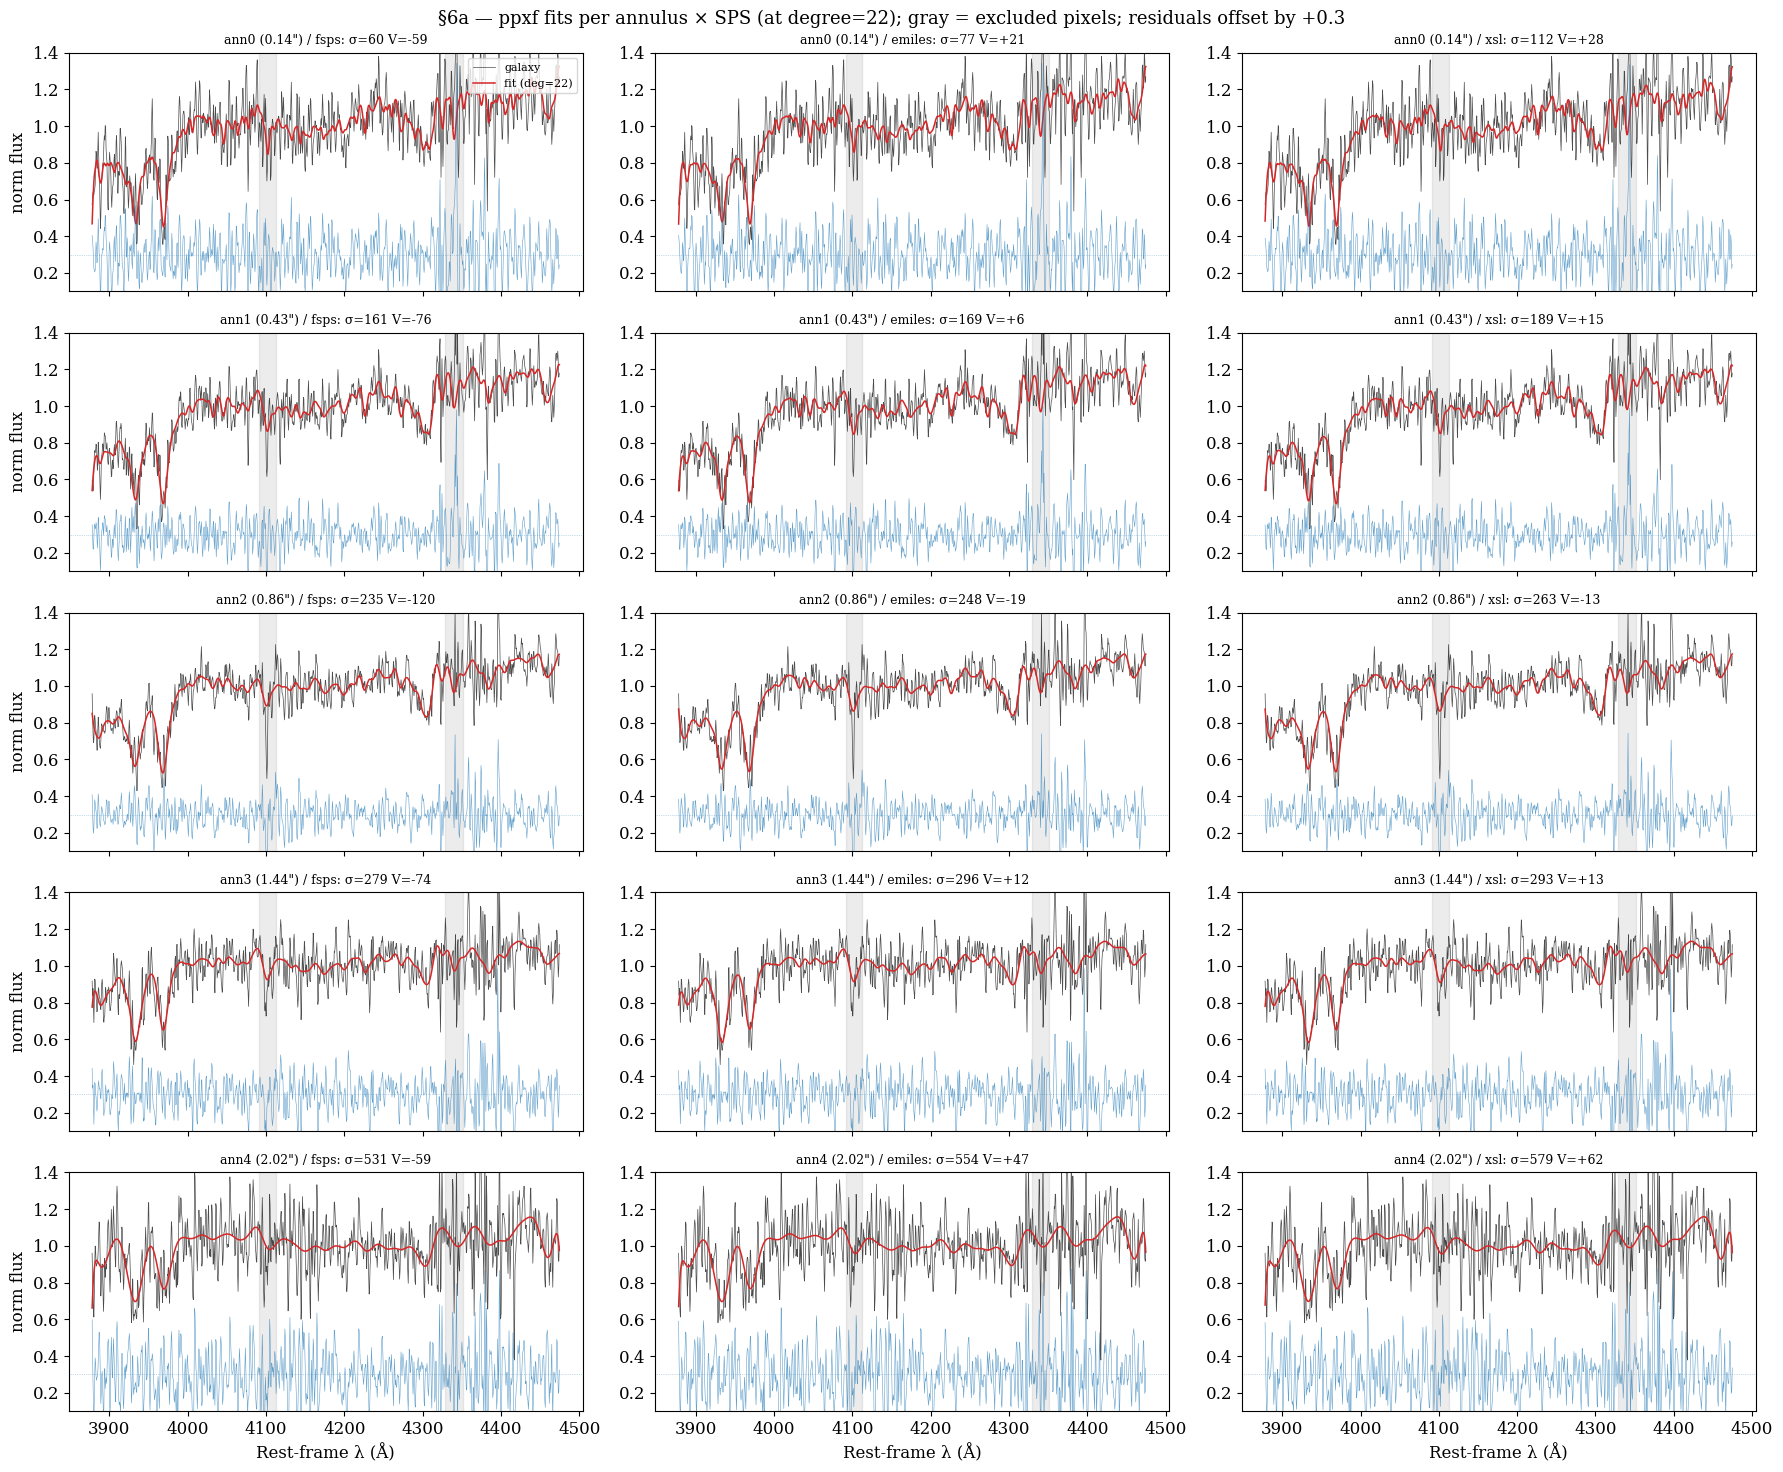

In [21]:
# §6a — example ppxf best-fits per annulus (degree=DEGREES[len//2]), one per SPS
# 5 annuli x 3 SPS = 15 panels
fig, axes = plt.subplots(len(annular_spectra), 3, figsize=(18, 3*len(annular_spectra)),
                         sharex=True)
if axes.ndim == 1: axes = axes[np.newaxis, :]
deg_show = int(DEGREES[len(DEGREES)//2])
for j in range(len(annular_spectra)):
    for i, sps in enumerate(SPS_LIBS):
        ax = axes[j, i]
        d = bootstrap_results[(j, sps)]
        deg_idx = int(np.where(d['degrees'] == deg_show)[0][0])
        lam_rest = d['lam_gal_rest']
        gp = d['goodpixels']
        bad = np.ones(len(lam_rest), dtype=bool); bad[gp] = False
        ax.plot(lam_rest, d['galaxy'], color='black', lw=0.5, alpha=0.7, label='galaxy')
        ax.plot(lam_rest, d['best_fit'][deg_idx], color='C3', lw=1.1, label=f'fit (deg={deg_show})')
        # Mark excluded
        ax.fill_between(lam_rest, 0, 2, where=bad, color='gray', alpha=0.15, step='mid')
        resid = d['galaxy'] - d['best_fit'][deg_idx]
        ax.plot(lam_rest, resid + 0.3, color='C0', lw=0.4, alpha=0.7)
        ax.axhline(0.3, color='C0', ls=':', lw=0.5, alpha=0.5)
        ax.set_title(f'ann{j} ({d["r_mid"]:.2f}\") / {sps}: '
                     f'σ={d["sig_orig"][deg_idx]:.0f} V={d["V_orig"][deg_idx]:+.0f}',
                     fontsize=9)
        if j == 0 and i == 0:
            ax.legend(fontsize=8, loc='upper right')
        ax.set_ylim(0.1, 1.4)
        if j == len(annular_spectra) - 1:
            ax.set_xlabel('Rest-frame λ (Å)')
        if i == 0:
            ax.set_ylabel('norm flux')

fig.suptitle(f'§6a — ppxf fits per annulus × SPS (at degree={deg_show}); '
             'gray = excluded pixels; residuals offset by +0.3', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s6_fits.png'), dpi=150, bbox_inches='tight')
plt.show()

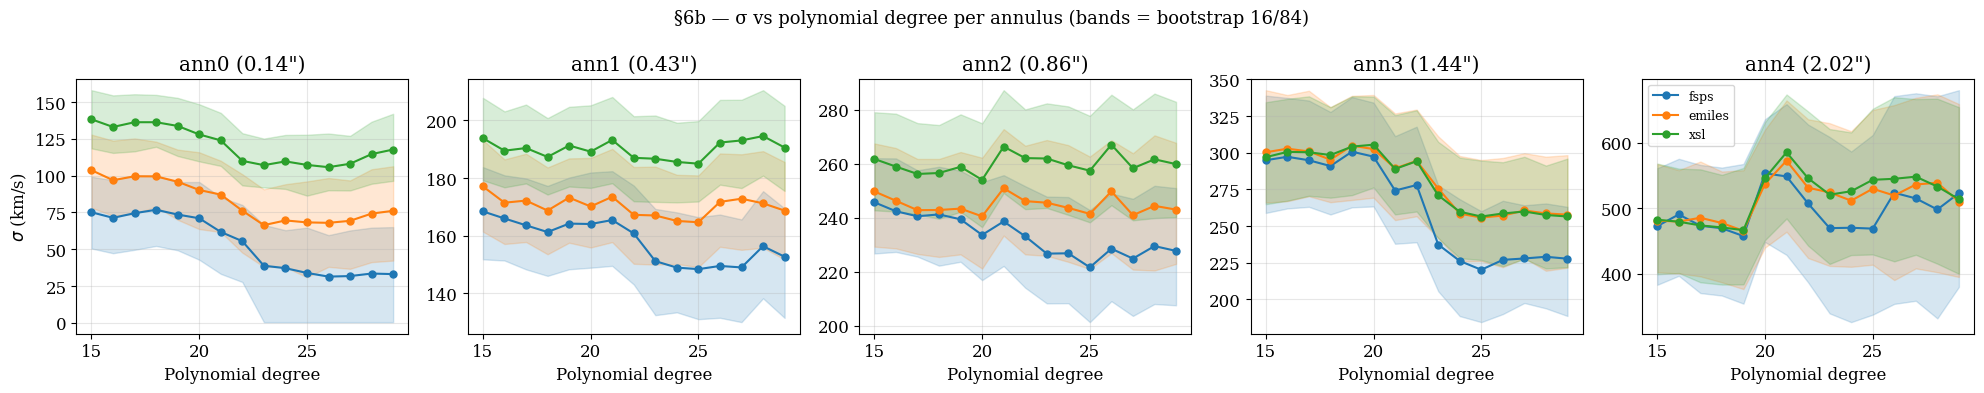

In [22]:
# §6b — σ vs polynomial degree, per annulus, per SPS
fig, axes = plt.subplots(1, len(annular_spectra), figsize=(4*len(annular_spectra), 4),
                         sharey=False)
if not hasattr(axes, '__len__'): axes = [axes]
sps_colors = {'fsps': 'C0', 'emiles': 'C1', 'xsl': 'C2'}
for j, ax in enumerate(axes):
    for sps in SPS_LIBS:
        d = bootstrap_results[(j, sps)]
        p16 = np.nanpercentile(d['sig_boot'], 16, axis=1)
        p50 = np.nanpercentile(d['sig_boot'], 50, axis=1)
        p84 = np.nanpercentile(d['sig_boot'], 84, axis=1)
        ax.fill_between(d['degrees'], p16, p84, color=sps_colors[sps], alpha=0.18)
        ax.plot(d['degrees'], p50, 'o-', color=sps_colors[sps], ms=5, label=sps)
    ax.set_xlabel('Polynomial degree'); ax.grid(alpha=0.3)
    ax.set_title(f'ann{j} ({annular_spectra[j]["r_mid"]:.2f}\")')
    if j == 0: ax.set_ylabel(r'$\sigma$ (km/s)')
    if j == len(axes) - 1: ax.legend(fontsize=9)
fig.suptitle('§6b — σ vs polynomial degree per annulus (bands = bootstrap 16/84)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s6_sig_vs_deg.png'), dpi=150, bbox_inches='tight')
plt.show()

Hard physical cap SIGMA_MAX_CAP = 400 km/s
Seeing-limit radius (FWHM/2) = 0.64"
Annulus 0 outer edge = 0.29" -> seeing-limited? True
  ann0 R=0.14" σ_pooled=89  *** SEEING_LIMITED ***
  ann1 R=0.43" σ_pooled=173  (ok)
  ann2 R=0.86" σ_pooled=246  (ok)
  ann3 R=1.44" σ_pooled=278  (ok)
  ann4 R=2.02" σ_pooled=507  *** FLAGGED_ARC (σ > SIGMA_MAX_CAP) ***


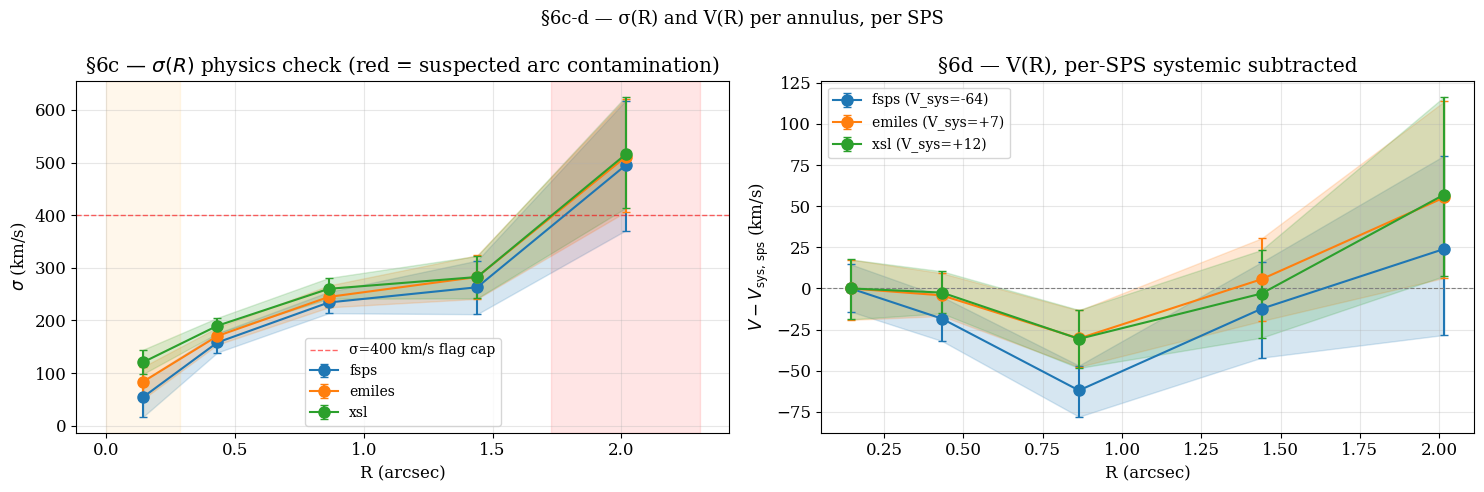


Flagged annulus indices (to also exclude from "filtered" σ_e): [4]


In [23]:
# §6c — σ(R) — the PHYSICS plot; decreasing = healthy, increasing = arc-contaminated
# Use median over all degrees (with bootstrap).
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Per-SPS σ(R) with 16/84 band
ax = axes[0]
sig_at_ann = {}  # sps -> (n_ann,) array of σ_p50 (pooled across degrees × bootstrap)
for sps in SPS_LIBS:
    sig_p50, sig_p16, sig_p84 = [], [], []
    for j in range(len(annular_spectra)):
        all_sig = bootstrap_results[(j, sps)]['sig_boot'].ravel()
        all_sig = all_sig[np.isfinite(all_sig)]
        sig_p16.append(np.percentile(all_sig, 16))
        sig_p50.append(np.percentile(all_sig, 50))
        sig_p84.append(np.percentile(all_sig, 84))
    sig_p16 = np.array(sig_p16); sig_p50 = np.array(sig_p50); sig_p84 = np.array(sig_p84)
    sig_at_ann[sps] = {'p16': sig_p16, 'p50': sig_p50, 'p84': sig_p84}
    ax.fill_between(r_mid_ann, sig_p16, sig_p84, color=sps_colors[sps], alpha=0.18)
    ax.errorbar(r_mid_ann, sig_p50, yerr=[sig_p50-sig_p16, sig_p84-sig_p50],
                fmt='o-', ms=8, color=sps_colors[sps], capsize=3, label=sps)

# Physics-prior flag: use a HARD PHYSICAL CAP at σ > SIGMA_MAX_CAP (unphysical for stellar kinematics).
# Also separately flag ann0 as SEEING_LIMITED — it's often sub-FWHM and noisy, so we
# do NOT use it as the reference for auto-thresholding.
SIGMA_MAX_CAP = 400.0   # km/s — physical ceiling; above this is definitely arc contamination
combined_sig_p50 = np.zeros(len(annular_spectra))
for j in range(len(annular_spectra)):
    pooled = np.concatenate([bootstrap_results[(j, sps)]['sig_boot'].ravel()
                             for sps in SPS_LIBS])
    pooled = pooled[np.isfinite(pooled)]
    combined_sig_p50[j] = np.median(pooled)

# Flag annuli that violate the physical cap (arc contamination)
flagged = combined_sig_p50 > SIGMA_MAX_CAP
# Also mark ann0 as seeing-limited if its outer edge is inside the seeing PSF half-FWHM
seeing_limit_arcsec = 0.5 * KCWI_SEEING_FWHM
ann0_seeing_limited = r_edges[1] < seeing_limit_arcsec

print(f'Hard physical cap SIGMA_MAX_CAP = {SIGMA_MAX_CAP:.0f} km/s')
print(f'Seeing-limit radius (FWHM/2) = {seeing_limit_arcsec:.2f}\"')
print(f'Annulus 0 outer edge = {r_edges[1]:.2f}\" -> seeing-limited? {ann0_seeing_limited}')
for j, (r, s, fl) in enumerate(zip(r_mid_ann, combined_sig_p50, flagged)):
    tags = []
    if fl: tags.append('FLAGGED_ARC (σ > SIGMA_MAX_CAP)')
    if j == 0 and ann0_seeing_limited: tags.append('SEEING_LIMITED')
    status = '  *** ' + ' + '.join(tags) + ' ***' if tags else '  (ok)'
    print(f'  ann{j} R={r:.2f}\" σ_pooled={s:.0f}{status}')
    if fl:
        ax.axvspan(r_edges[j], r_edges[j+1], color='red', alpha=0.1)
    elif j == 0 and ann0_seeing_limited:
        ax.axvspan(r_edges[j], r_edges[j+1], color='orange', alpha=0.08)

sig_central = combined_sig_p50[0]  # kept for reference only, not used as threshold

ax.axhline(SIGMA_MAX_CAP, color='red', ls='--', lw=1.0, alpha=0.6,
           label=f'σ={SIGMA_MAX_CAP:.0f} km/s flag cap')
ax.set_xlabel('R (arcsec)'); ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title(r'§6c — $\sigma(R)$ physics check (red = suspected arc contamination)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# V(R)
ax = axes[1]
V_at_ann = {}
for sps in SPS_LIBS:
    V_p50, V_p16, V_p84 = [], [], []
    for j in range(len(annular_spectra)):
        all_V = bootstrap_results[(j, sps)]['V_boot'].ravel()
        all_V = all_V[np.isfinite(all_V)]
        V_p16.append(np.percentile(all_V, 16))
        V_p50.append(np.percentile(all_V, 50))
        V_p84.append(np.percentile(all_V, 84))
    V_p16 = np.array(V_p16); V_p50 = np.array(V_p50); V_p84 = np.array(V_p84)
    V_at_ann[sps] = {'p16': V_p16, 'p50': V_p50, 'p84': V_p84}
    # Subtract central V of this SPS (split-track)
    V_sys_sps = V_p50[0]
    ax.fill_between(r_mid_ann, V_p16 - V_sys_sps, V_p84 - V_sys_sps,
                    color=sps_colors[sps], alpha=0.18)
    ax.errorbar(r_mid_ann, V_p50 - V_sys_sps,
                yerr=[V_p50-V_p16, V_p84-V_p50], fmt='o-', ms=8,
                color=sps_colors[sps], capsize=3, label=f'{sps} (V_sys={V_sys_sps:+.0f})')
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel(r'$V - V_{\rm sys,\,sps}$ (km/s)')
ax.set_title('§6d — V(R), per-SPS systemic subtracted')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

fig.suptitle('§6c-d — σ(R) and V(R) per annulus, per SPS', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s6_sig_V_vs_R.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save the flag for §7
FLAGGED_ANNULI = np.where(flagged)[0].tolist()
print(f'\nFlagged annulus indices (to also exclude from "filtered" σ_e): {FLAGGED_ANNULI}')

### §6 (cumulative track) — ppxf on I-weighted cumulative apertures

The annular path (§5-§6 above) measures σ(r) per ring and then discretizes Gültekin's integral. The **cumulative path** sweeps R_max through `r_edges[1:]` = {Re/8, Re/4, Re/2, 3Re/4, Re}, and for each R_max:

1. Averages cube spaxels within R < R_max, **weighted by I(r)** per spaxel (IFU 6500-7500 Å band = headline I-weight, × the same `1 − spaxel_contam` arc weighting).
2. Runs ppxf + bootstrap → returns a single (V, σ) per (R_max, SPS).

The fitted σ IS the Gültekin σ_e(<R_max) directly (because I-weighted aggregation of individual-spaxel LOSVDs, when fit with ppxf, recovers the I-weighted quadrature of V² + σ² — which is exactly Gültekin eq. 1).

This is the physically-motivated path the user asked for. Both paths are reported and compared at the end of §7.

In [24]:
# Extract I(r)-weighted cumulative aperture spectra for R_max in r_edges[1:]
# I-weight = IFU 6500-7500 Å band value per spaxel (the headline I-source).
# Additional arc-contamination weight = (1 − spaxel_contam), clipped to [0.01, 1].

I_weight_spax = np.clip(ifu_band, 0, None)  # 2D map, same as I_headline once §7 defines it
arc_weight_spax = np.clip(1.0 - spaxel_contam, 0.01, 1.0)

cum_apertures = []  # list of dicts with r_max, flux, noise, n_spax, w_sum, ...
for r_max in r_edges[1:]:
    sel = r_spax < r_max
    n_j = int(sel.sum())
    if n_j < 1:
        continue
    w = I_weight_spax[sel] * arc_weight_spax[sel]
    w_norm = w / max(w.sum(), 1e-30)
    # Weighted sum along spatial axes
    flux = np.sum(cube[:, sel] * w_norm[None, :], axis=1)
    cum_apertures.append({
        'r_max': r_max,
        'flux': flux,
        'noise': noise_sky.copy(),  # same sky-derived noise used in §5
        'n_spax': n_j,
        'w_sum': float(w.sum()),
        'w_mean': float(w.mean()),
    })
    sn_band = np.median(flux[band_mask]) / np.median(noise_sky[band_mask])
    print(f'Cum aperture R<{r_max:.3f}\" : N_spax={n_j:3d}  '
          f'w_mean={w.mean():.3f}  S/N_band={sn_band:.1f}')

Cum aperture R<0.288" : N_spax=  3  w_mean=16.193  S/N_band=7.2
Cum aperture R<0.576" : N_spax= 11  w_mean=14.888  S/N_band=6.9
Cum aperture R<1.152" : N_spax= 45  w_mean=11.909  S/N_band=5.7
Cum aperture R<1.728" : N_spax=104  w_mean=9.051  S/N_band=4.7
Cum aperture R<2.305" : N_spax=184  w_mean=7.142  S/N_band=4.0


In [25]:
# ppxf + bootstrap per cumulative aperture, per SPS (same pattern as §6 but on cum spectra)
# FAST-PATH: reload from disk if cache files exist
cum_bootstrap = {}
_cum_dir = ANNULAR_DIR  # reuse same subdirectory
_cum_files_exist = all(
    os.path.exists(os.path.join(_cum_dir, f'cumR_{a["r_max"]:.3f}_{sps}.npz'.replace('.', 'p', 1)))
    for a in cum_apertures for sps in SPS_LIBS
)
if _cum_files_exist:
    print(f'FAST-PATH: reloading cum_bootstrap from {_cum_dir} ...')
    for j, a in enumerate(cum_apertures):
        for sps in SPS_LIBS:
            fn = os.path.join(_cum_dir, f'cumR_{a["r_max"]:.3f}_{sps}.npz'.replace('.', 'p', 1))
            d = dict(np.load(fn, allow_pickle=True))
            for k in list(d.keys()):
                if d[k].shape == ():
                    d[k] = d[k].item()
            cum_bootstrap[(j, sps)] = d
            print(f'  loaded cum R<{a["r_max"]:.2f}\" / {sps}')
    print('FAST-PATH DONE.')
else:
    t_cum0 = clock()
    for j, a in enumerate(cum_apertures):
        for sps in SPS_LIBS:
            t0 = clock()
            inputs = setup_ppxf_inputs_from_spectrum(
                a['flux'], a['noise'], hdr, sps_name=sps, z=Z_SYSTEMIC, verbose=False)
            n_pix = len(inputs['galaxy']); n_deg = len(DEGREES)
            bf = np.zeros((n_deg, n_pix))
            V_o = np.zeros(n_deg); sig_o = np.zeros(n_deg); chi_o = np.zeros(n_deg)
            V_b = np.full((n_deg, N_BOOTSTRAP), np.nan)
            sig_b = np.full((n_deg, N_BOOTSTRAP), np.nan)
            for i, deg in enumerate(DEGREES):
                pp = ppxf(inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
                         inputs['velscale'], inputs['start'],
                         goodpixels=inputs['goodpixels'], plot=False, moments=2,
                         trig=False, degree=int(deg), mdegree=0,
                         lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=True)
                bf[i] = pp.bestfit; V_o[i] = pp.sol[0]; sig_o[i] = pp.sol[1]; chi_o[i] = pp.chi2
                rb = run_bootstrap_single_degree(
                    inputs, degree=int(deg), best_fit_spectrum=pp.bestfit,
                    n_bootstrap=N_BOOTSTRAP, window=WINDOW,
                    seed=BOOT_SEED + 1000 + 100*j + i)
                V_b[i] = rb['V_samples']; sig_b[i] = rb['sigma_samples']
            cum_bootstrap[(j, sps)] = {
                'V_orig': V_o, 'sig_orig': sig_o, 'chi2_orig': chi_o,
                'V_boot': V_b, 'sig_boot': sig_b, 'best_fit': bf,
                'galaxy': inputs['galaxy'], 'noise': inputs['noise'],
                'lam_gal_rest': inputs['lam_gal_rest'], 'goodpixels': inputs['goodpixels'],
                'degrees': np.asarray(DEGREES), 'r_max': a['r_max'], 'sps': sps,
            }
            # Save to disk for fast-path reload next time
            fn = os.path.join(_cum_dir, f'cumR_{a["r_max"]:.3f}_{sps}.npz'.replace('.', 'p', 1))
            np.savez(fn,
                     **{k: v for k, v in cum_bootstrap[(j, sps)].items() if k != 'goodpixels'},
                     goodpixels=cum_bootstrap[(j, sps)]['goodpixels'])
            print(f'  cum R<{a["r_max"]:.2f}\" / {sps}: '
                  f'σ={sig_o.min():.0f}-{sig_o.max():.0f}  {clock()-t0:.1f}s')
    print(f'\n§6-cumulative total: {(clock()-t_cum0)/60:.1f} min')

FAST-PATH: reloading cum_bootstrap from ../results/annular_bootstrap ...
  loaded cum R<0.29" / fsps
  loaded cum R<0.29" / emiles
  loaded cum R<0.29" / xsl
  loaded cum R<0.58" / fsps
  loaded cum R<0.58" / emiles
  loaded cum R<0.58" / xsl
  loaded cum R<1.15" / fsps
  loaded cum R<1.15" / emiles
  loaded cum R<1.15" / xsl
  loaded cum R<1.73" / fsps
  loaded cum R<1.73" / emiles
  loaded cum R<1.73" / xsl
  loaded cum R<2.30" / fsps
  loaded cum R<2.30" / emiles
  loaded cum R<2.30" / xsl
FAST-PATH DONE.


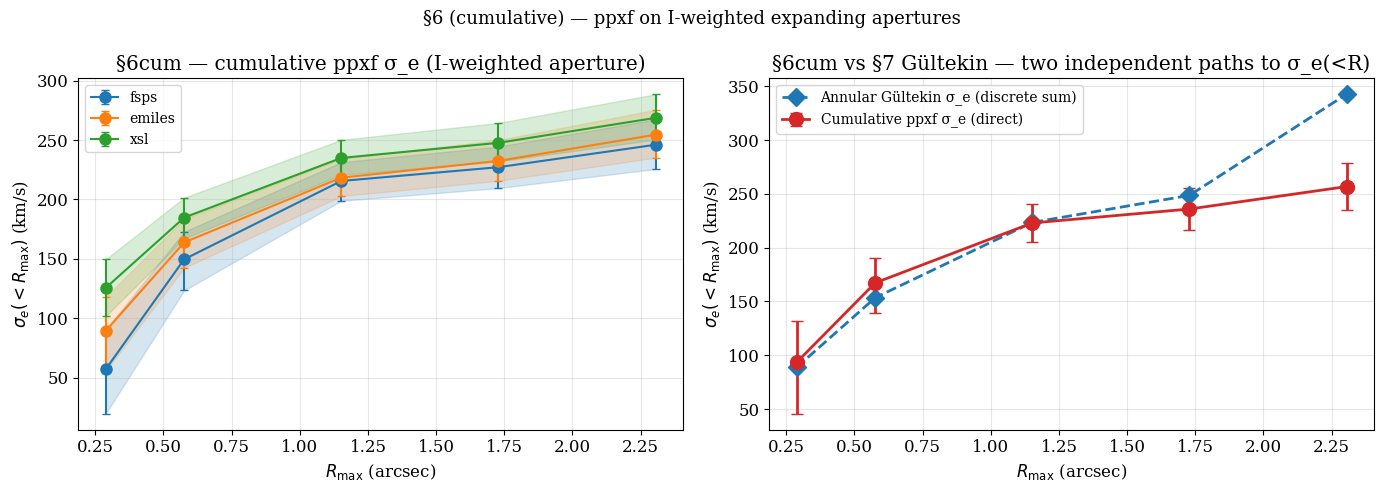


 R_max (arcsec)   cum ppxf σ_e (combined)   annular Gültekin σ_e
-----------------------------------------------------------------
          0.288    93 -48/+38 km/s               89 km/s
          0.576   167 -28/+23 km/s              154 km/s
          1.152   223 -18/+18 km/s              223 km/s
          1.728   236 -19/+19 km/s              249 km/s
          2.305   257 -22/+22 km/s              343 km/s


In [26]:
# Plot cumulative σ(<R) per SPS (the direct ppxf result)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
r_cum = [a['r_max'] for a in cum_apertures]

# Panel a — σ_cum vs R per SPS (pool across degrees+bootstrap for percentiles)
ax = axes[0]
cum_sig_at_R = {}  # sps -> {'p16', 'p50', 'p84'} arrays of shape (n_aper,)
for sps in SPS_LIBS:
    p16, p50, p84 = [], [], []
    for j in range(len(cum_apertures)):
        all_sig = cum_bootstrap[(j, sps)]['sig_boot'].ravel()
        all_sig = all_sig[np.isfinite(all_sig)]
        p16.append(np.percentile(all_sig, 16))
        p50.append(np.percentile(all_sig, 50))
        p84.append(np.percentile(all_sig, 84))
    p16, p50, p84 = np.array(p16), np.array(p50), np.array(p84)
    cum_sig_at_R[sps] = {'p16': p16, 'p50': p50, 'p84': p84}
    ax.fill_between(r_cum, p16, p84, color=sps_colors[sps], alpha=0.18)
    ax.errorbar(r_cum, p50, yerr=[p50-p16, p84-p50], fmt='o-', ms=8,
                color=sps_colors[sps], capsize=3, label=sps)
ax.set_xlabel(r'$R_{\rm max}$ (arcsec)')
ax.set_ylabel(r'$\sigma_e(<R_{\rm max})$ (km/s)')
ax.set_title('§6cum — cumulative ppxf σ_e (I-weighted aperture)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Panel b — compare cumulative vs annular-Gültekin (both at each r_max in r_edges[1:])
# The annular one is computed in §7 but here we can do a quick combined-SPS comparison
# using the sig_at_ann from §6c and F_j from §7 (which are computed later; use ifu_band here)
ax = axes[1]
# For each R_max, compute Gültekin σ_e from annular sig_at_ann (combined across SPS)
Fj_local = np.array([ifu_band[(r_spax >= r_edges[jj]) & (r_spax < r_edges[jj+1])].sum()
                     for jj in range(n_ann)])
sig_ann_Rmax = []
for r_max in r_cum:
    j_use = [jj for jj in range(n_ann) if r_edges[jj+1] <= r_max + 1e-6]
    if not j_use:
        sig_ann_Rmax.append(np.nan); continue
    F_tot = Fj_local[j_use].sum()
    # Combined-SPS V_rms² per annulus — use V_p50 and sig_p50 from sig_at_ann (computed in §6c)
    num = 0
    for j in j_use:
        # pooled across SPS
        V_pool = np.concatenate([bootstrap_results[(j, sps)]['V_boot'].ravel() for sps in SPS_LIBS])
        S_pool = np.concatenate([bootstrap_results[(j, sps)]['sig_boot'].ravel() for sps in SPS_LIBS])
        V_pool = V_pool[np.isfinite(V_pool)]; S_pool = S_pool[np.isfinite(S_pool)]
        V_med = np.median(V_pool); S_med = np.median(S_pool)
        # V_sys proxy = V_med of ann0
        V0_pool = np.concatenate([bootstrap_results[(0, sps)]['V_boot'].ravel() for sps in SPS_LIBS])
        V0 = np.median(V0_pool[np.isfinite(V0_pool)])
        num += Fj_local[j] * ((V_med - V0)**2 + S_med**2)
    sig_ann_Rmax.append(np.sqrt(num / F_tot))
sig_ann_Rmax = np.array(sig_ann_Rmax)

# Cumulative σ combined across SPS (pooled posteriors)
sig_cum_Rmax_p50 = []
sig_cum_Rmax_p16 = []
sig_cum_Rmax_p84 = []
for j in range(len(cum_apertures)):
    pool = np.concatenate([cum_bootstrap[(j, sps)]['sig_boot'].ravel() for sps in SPS_LIBS])
    pool = pool[np.isfinite(pool)]
    sig_cum_Rmax_p50.append(np.percentile(pool, 50))
    sig_cum_Rmax_p16.append(np.percentile(pool, 16))
    sig_cum_Rmax_p84.append(np.percentile(pool, 84))
sig_cum_Rmax_p50 = np.array(sig_cum_Rmax_p50)
sig_cum_Rmax_p16 = np.array(sig_cum_Rmax_p16)
sig_cum_Rmax_p84 = np.array(sig_cum_Rmax_p84)

ax.errorbar(r_cum, sig_cum_Rmax_p50,
            yerr=[sig_cum_Rmax_p50-sig_cum_Rmax_p16, sig_cum_Rmax_p84-sig_cum_Rmax_p50],
            fmt='o-', ms=10, color='C3', capsize=4, lw=2,
            label='Cumulative ppxf σ_e (direct)')
ax.plot(r_cum, sig_ann_Rmax, 'D--', ms=9, color='C0', lw=2,
        label='Annular Gültekin σ_e (discrete sum)')
ax.set_xlabel(r'$R_{\rm max}$ (arcsec)')
ax.set_ylabel(r'$\sigma_e(<R_{\rm max})$ (km/s)')
ax.set_title('§6cum vs §7 Gültekin — two independent paths to σ_e(<R)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

fig.suptitle('§6 (cumulative) — ppxf on I-weighted expanding apertures', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s6cum_sigma_vs_R.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print the summary table
print(f'\n{"R_max (arcsec)":>15} {"cum ppxf σ_e (combined)":>25} {"annular Gültekin σ_e":>22}')
print('-' * 65)
for j, r_max in enumerate(r_cum):
    print(f'{r_max:>15.3f} '
          f'{sig_cum_Rmax_p50[j]:>5.0f} -{sig_cum_Rmax_p50[j]-sig_cum_Rmax_p16[j]:.0f}/+{sig_cum_Rmax_p84[j]-sig_cum_Rmax_p50[j]:.0f} km/s   '
          f'{sig_ann_Rmax[j]:>14.0f} km/s')

## §7. Explicit Gültekin integral

Discretized:
$$\sigma_e^2(<R_{\max}) \;=\; \frac{\sum_j F_j \, [(V_j - V_{\rm sys})^2 + \sigma_j^2]}{\sum_j F_j}$$

with $F_j = \int_{\rm annulus\,j} I(r) \, 2\pi r \, dr$ — the I-weighted flux in the annulus.  Sum runs over annuli with outer edge $\le R_{\max}$.

MC propagation: per SPS, draw (V_j, σ_j) by picking a random (degree, bootstrap-index) from the saved posteriors. V_sys_per_SPS = central annulus median V for that SPS.

Report per-SPS σ_e, combined-SPS σ_e, and the "filtered" variant that drops flagged annuli from §6c.

In [27]:
# Build headline I(r) map: IFU 6500-7500 Å band on the IFU grid (unmasked)
# This is the I(r) that weights the Gültekin sum.
I_headline = np.clip(ifu_band, 0, None)
print(f'Headline I(r) = IFU 6500-7500 Å band, shape {I_headline.shape}, '
      f'sum {I_headline.sum():.3e}')

# Compute F_j = Σ I(spaxel) over each annulus (the discretized ∫ I(r) 2πr dr)
# The "2πr dr" factor is implicit in the spaxel counting — spaxels at larger R
# are at larger circumference, so they are automatically represented proportionally.
F_j = np.zeros(len(annular_spectra))
for j in range(len(annular_spectra)):
    ann_mask = (r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])
    F_j[j] = I_headline[ann_mask].sum()
print('\nI-weighted flux per annulus (F_j):')
for j, (r, f) in enumerate(zip(r_mid_ann, F_j)):
    print(f'  ann{j} R={r:.2f}\" F_j = {f:.3e}  ({100*f/F_j.sum():.1f}% of total)')
print(f'  total F = {F_j.sum():.3e}')

Headline I(r) = IFU 6500-7500 Å band, shape (100, 100), sum 4.855e+03

I-weighted flux per annulus (F_j):
  ann0 R=0.14" F_j = 6.539e+01  (3.6% of total)
  ann1 R=0.43" F_j = 1.579e+02  (8.7% of total)
  ann2 R=0.86" F_j = 5.065e+02  (28.0% of total)
  ann3 R=1.44" F_j = 5.688e+02  (31.4% of total)
  ann4 R=2.02" F_j = 5.113e+02  (28.2% of total)
  total F = 1.810e+03


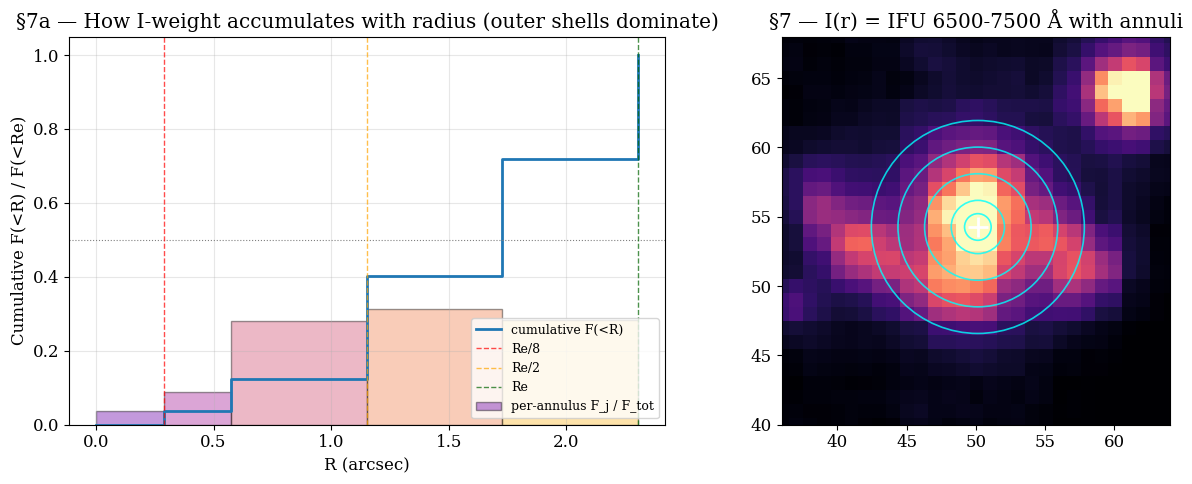

In [28]:
# Plot §7a: F_j/F_total cumulative distribution — shows how much the OUTER shells dominate
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
F_cum = np.cumsum(F_j) / F_j.sum()
ax.step(np.concatenate([[0], r_edges[1:]]), np.concatenate([[0], F_cum]),
        where='post', lw=2, color='C0', label='cumulative F(<R)')
ax.bar(r_mid_ann, F_j/F_j.sum(), width=np.diff(r_edges), alpha=0.4,
       color=plt.cm.plasma(np.linspace(0.2, 0.85, len(F_j))), edgecolor='black',
       label='per-annulus F_j / F_tot')
ax.axhline(0.5, color='gray', ls=':', lw=0.8)
for tag, r_val, c in [('Re/8', r_edges[1], 'red'), ('Re/2', r_edges[3], 'orange'),
                      ('Re', r_edges[-1], 'darkgreen')]:
    ax.axvline(r_val, color=c, ls='--', lw=1.0, alpha=0.7, label=tag)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel('Cumulative F(<R) / F(<Re)')
ax.set_title('§7a — How I-weight accumulates with radius (outer shells dominate)')
ax.legend(fontsize=9, loc='lower right'); ax.grid(alpha=0.3)

# Also show the I-weight 2D map with annuli overlaid
ax = axes[1]
delta = 14
y1 = max(0, int(cy_ifu - delta)); y2 = min(ny, int(cy_ifu + delta))
x1 = max(0, int(cx_ifu - delta)); x2 = min(nx, int(cx_ifu + delta))
ax.imshow(I_headline, origin='lower', cmap='magma',
          extent=[-0.5, nx-0.5, -0.5, ny-0.5],
          vmin=0, vmax=np.percentile(I_headline[I_headline>0], 99))
for j in range(len(annular_spectra)):
    ax.add_patch(Circle((cx_ifu, cy_ifu), r_edges[j+1]/pix_scale_ifu,
                        fill=False, edgecolor='cyan', lw=1.2, alpha=0.8))
ax.plot(cx_ifu, cy_ifu, 'w+', ms=14, mew=2)
ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
ax.set_title('§7 — I(r) = IFU 6500-7500 Å with annuli')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s7_I_weight.png'), dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# §7 — Monte-Carlo the Gültekin integral. One draw per MC step per SPS:
# - Pick a random (degree_idx, bootstrap_idx) from each annulus's saved posterior
# - Compute V_sys_SPS = V_j at the central (innermost) annulus
# - σ_e²_draw(<R_max) = Σ_{j: r_outer<=R_max} F_j × [(V_j - V_sys)² + σ_j²] / Σ F_j

APERTURES = {'Re8': R_E/8, 'Re2': R_E/2, 'Re': R_E}

def run_gultekin_mc(bootstrap_results, F_j, r_edges, apertures,
                    sps_list=SPS_LIBS, n_mc=N_MC, seed=123,
                    filter_annuli=None):
    """Returns: samples[(sps, tag)] = 1-D array of σ_e posterior samples; V_offsets[sps].
    If filter_annuli is given (list of ann_idx to DROP), those annuli are excluded."""
    rng = np.random.default_rng(seed)
    n_ann = len(r_edges) - 1
    n_deg, n_boot = bootstrap_results[(0, sps_list[0])]['sig_boot'].shape

    # Annuli kept
    keep_ann = [j for j in range(n_ann) if (filter_annuli is None or j not in filter_annuli)]

    samples = {}
    V_offsets = {}
    for sps in sps_list:
        # Draw (V, σ) per annulus for this SPS
        V_draws = np.zeros((n_mc, n_ann))
        S_draws = np.zeros((n_mc, n_ann))
        for j in range(n_ann):
            if j not in keep_ann: continue
            d = bootstrap_results[(j, sps)]
            # Random (degree, bootstrap) draws
            di = rng.integers(0, n_deg, size=n_mc)
            bi = rng.integers(0, n_boot, size=n_mc)
            V_draws[:, j] = d['V_boot'][di, bi]
            S_draws[:, j] = d['sig_boot'][di, bi]

        # Per-SPS V_sys: central (innermost kept) annulus's V, per-draw median
        j_central = keep_ann[0]
        V_sys_draws = V_draws[:, j_central]
        # Use a single V_sys per SPS (median across draws) for the split-track
        V_sys_SPS = float(np.nanmedian(V_sys_draws))
        V_offsets[sps] = V_sys_SPS

        # σ_e per aperture
        for tag, r_max in apertures.items():
            j_use = [j for j in keep_ann if r_edges[j+1] <= r_max + 1e-6]
            if not j_use:
                samples[(sps, tag)] = np.full(n_mc, np.nan)
                continue
            F_sum = F_j[j_use].sum()
            num = np.zeros(n_mc)
            for j in j_use:
                num += F_j[j] * ((V_draws[:, j] - V_sys_SPS)**2 + S_draws[:, j]**2)
            sigma_e = np.sqrt(num / F_sum)
            samples[(sps, tag)] = sigma_e
    return samples, V_offsets


# Run unfiltered (all annuli)
sam_unf, V_off_unf = run_gultekin_mc(bootstrap_results, F_j, r_edges, APERTURES,
                                      n_mc=N_MC, seed=123, filter_annuli=None)
# Run filtered (drop flagged annuli)
sam_flt, V_off_flt = run_gultekin_mc(bootstrap_results, F_j, r_edges, APERTURES,
                                      n_mc=N_MC, seed=124,
                                      filter_annuli=FLAGGED_ANNULI)

# Print headline block
print('=' * 78)
print('σ_e (Gültekin 2009 / KH13) — EXPLICIT RADIAL-ANNULUS INTEGRAL')
print('=' * 78)
print(f'\nI(r) source: IFU 6500-7500 Å band (unmasked), with 5 radial annuli on IFU grid.')
print(f'Headline R_e = {R_E:.3f}\" = {R_E*KPC_PER_ARCSEC:.2f} kpc  '
      f'(mean of F140W + F200LP masked).')
print(f'Flagged annuli (σ > 400 km/s physical cap — suspected arc contamination): {FLAGGED_ANNULI}')
print(f'Per-SPS V_sys offsets (ann 0 V_p50):')
for sps, V in V_off_unf.items():
    print(f'  {sps:8s}: {V:+.1f} km/s')

for mode, samples in [('UNFILTERED (all 5 annuli)', sam_unf),
                      (f'FILTERED (drop {FLAGGED_ANNULI})', sam_flt)]:
    print(f'\n--- {mode} ---')
    for tag in APERTURES:
        print(f'  σ_e(<{tag}):')
        for sps in SPS_LIBS:
            s = samples[(sps, tag)]; s = s[np.isfinite(s)]
            if len(s) == 0:
                print(f'    {sps:8s}:  [no valid draws]'); continue
            p16, p50, p84 = np.percentile(s, [16, 50, 84])
            print(f'    {sps:8s}:  {p50:.0f}  -{p50-p16:.0f}/+{p84-p50:.0f} km/s')
        # combined
        pool = np.concatenate([samples[(sps, tag)][np.isfinite(samples[(sps, tag)])]
                               for sps in SPS_LIBS])
        if len(pool) == 0: continue
        p16, p50, p84 = np.percentile(pool, [16, 50, 84])
        print(f'    {"combined":8s}:  {p50:.0f}  -{p50-p16:.0f}/+{p84-p50:.0f} km/s')

# Store for §9
sigma_e_samples = {'unfiltered': sam_unf, 'filtered': sam_flt}
V_offsets = {'unfiltered': V_off_unf, 'filtered': V_off_flt}

σ_e (Gültekin 2009 / KH13) — EXPLICIT RADIAL-ANNULUS INTEGRAL

I(r) source: IFU 6500-7500 Å band (unmasked), with 5 radial annuli on IFU grid.
Headline R_e = 2.305" = 16.23 kpc  (mean of F140W + F200LP masked).
Flagged annuli (σ > 400 km/s physical cap — suspected arc contamination): [4]
Per-SPS V_sys offsets (ann 0 V_p50):
  fsps    : -64.5 km/s
  emiles  : +7.2 km/s
  xsl     : +13.6 km/s

--- UNFILTERED (all 5 annuli) ---
  σ_e(<Re8):
    fsps    :  59  -35/+29 km/s
    emiles  :  87  -32/+29 km/s
    xsl     :  122  -22/+23 km/s
    combined:  91  -45/+37 km/s
  σ_e(<Re2):
    fsps    :  216  -17/+15 km/s
    emiles  :  223  -16/+17 km/s
    xsl     :  240  -14/+17 km/s
    combined:  226  -19/+19 km/s
  σ_e(<Re):
    fsps    :  339  -49/+54 km/s
    emiles  :  345  -40/+51 km/s
    xsl     :  357  -40/+47 km/s
    combined:  348  -44/+50 km/s

--- FILTERED (drop [4]) ---
  σ_e(<Re8):
    fsps    :  54  -35/+34 km/s
    emiles  :  85  -33/+29 km/s
    xsl     :  122  -20/+22 km/s
 

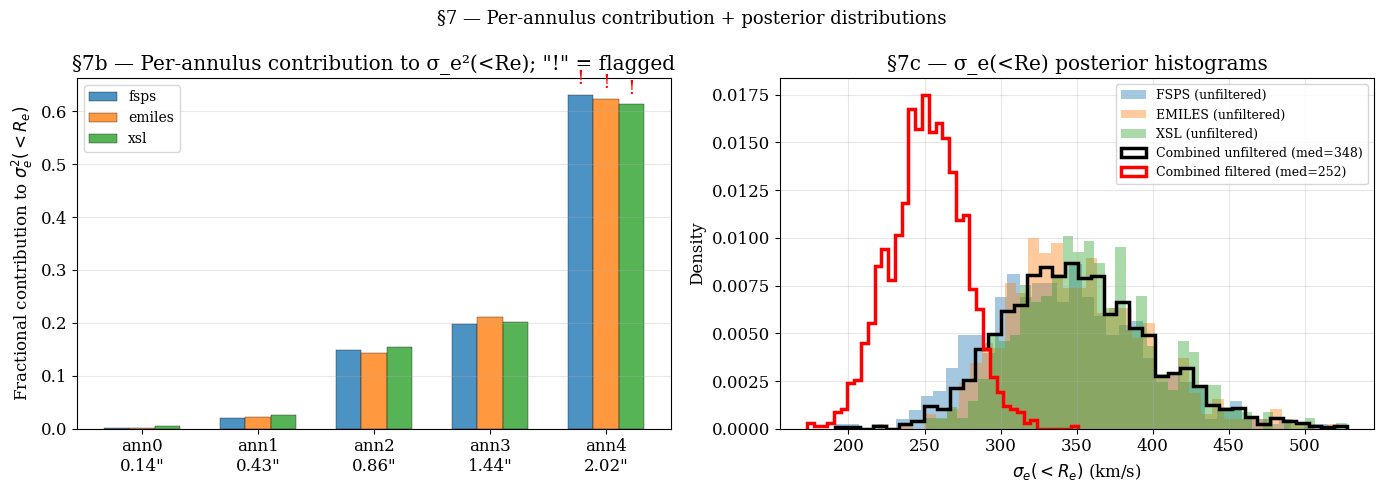

In [30]:
# §7b,c — per-annulus contribution breakdown + posterior histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (b) Fractional contribution to σ_e² at R=Re, per annulus, per SPS
ax = axes[0]
tag = 'Re'
width = 0.22
x = np.arange(len(annular_spectra))
for i, sps in enumerate(SPS_LIBS):
    d_contribs = []
    V_sys = V_off_unf[sps]
    for j in range(len(annular_spectra)):
        # Median V_rms at this annulus for this SPS
        V_arr = bootstrap_results[(j, sps)]['V_boot'].ravel()
        S_arr = bootstrap_results[(j, sps)]['sig_boot'].ravel()
        good = np.isfinite(V_arr) & np.isfinite(S_arr)
        V_med = np.median(V_arr[good]); S_med = np.median(S_arr[good])
        V_rms2 = (V_med - V_sys)**2 + S_med**2
        d_contribs.append(F_j[j] * V_rms2)
    d_contribs = np.array(d_contribs) / np.sum(d_contribs)
    bars = ax.bar(x + (i-1)*width, d_contribs, width, label=sps,
                  color={'fsps':'C0','emiles':'C1','xsl':'C2'}[sps], alpha=0.8,
                  edgecolor='black', lw=0.3)
    # Mark flagged annuli
    for j in FLAGGED_ANNULI:
        ax.text(x[j] + (i-1)*width, d_contribs[j] + 0.02, '!', color='red',
                ha='center', fontsize=14)
ax.set_xticks(x); ax.set_xticklabels([f'ann{j}\n{r:.2f}\"' for j, r in enumerate(r_mid_ann)])
ax.set_ylabel(r'Fractional contribution to $\sigma_e^2(<R_e)$')
ax.set_title('§7b — Per-annulus contribution to σ_e²(<Re); "!" = flagged')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')

# (c) Posterior histograms of σ_e(<Re): per SPS + combined + filtered-combined
ax = axes[1]
ax.hist(sam_unf[('fsps', 'Re')], bins=40, alpha=0.4, color='C0', label='FSPS (unfiltered)', density=True)
ax.hist(sam_unf[('emiles', 'Re')], bins=40, alpha=0.4, color='C1', label='EMILES (unfiltered)', density=True)
ax.hist(sam_unf[('xsl', 'Re')], bins=40, alpha=0.4, color='C2', label='XSL (unfiltered)', density=True)
# Combined
pool_unf = np.concatenate([sam_unf[(sps,'Re')][np.isfinite(sam_unf[(sps,'Re')])] for sps in SPS_LIBS])
pool_flt = np.concatenate([sam_flt[(sps,'Re')][np.isfinite(sam_flt[(sps,'Re')])] for sps in SPS_LIBS])
ax.hist(pool_unf, bins=40, histtype='step', color='black', lw=2.5, density=True,
        label=f'Combined unfiltered (med={np.median(pool_unf):.0f})')
ax.hist(pool_flt, bins=40, histtype='step', color='red', lw=2.5, density=True,
        label=f'Combined filtered (med={np.median(pool_flt):.0f})')
ax.set_xlabel(r'$\sigma_e(<R_e)$ (km/s)')
ax.set_ylabel('Density')
ax.set_title('§7c — σ_e(<Re) posterior histograms')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('§7 — Per-annulus contribution + posterior distributions', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s7_posterior.png'), dpi=150, bbox_inches='tight')
plt.show()

## §8. I(r) source systematic

Repeat §7 with three different I(r) maps — IFU 6500-7500 Å (headline), F140W (reprojected, unmasked), F200LP (reprojected, unmasked) — to quantify the I-source spread.

In [31]:
# Build three I-maps for comparison
def reproject_hst_to_ifu(img_hst, wcs_hst_, ny_=ny, nx_=nx, wcs_ifu_=wcs_ifu):
    yy, xx = np.mgrid[:ny_, :nx_]
    ra, dec = wcs_ifu_.pixel_to_world_values(xx.ravel(), yy.ravel())
    xh, yh = wcs_hst_.world_to_pixel_values(ra, dec)
    I = map_coordinates(np.nan_to_num(img_hst), [yh, xh],
                        order=1, mode='constant', cval=0.0).reshape(ny_, nx_)
    return np.clip(I, 0, None)

# The user built the original ARC MASK on F200LP data; that mask is arc-only
# (deflector core is NOT flagged), unlike the F140W _mask.fits. So F200LP with
# its own mask applied BEFORE reprojection is a physically-motivated arc-cleaned
# I-weight.
img_f200_masked = np.where(mask_f200, 0.0, img_f200)
img_f140_masked = np.where(mask_f140, 0.0, img_f140)  # WARNING: F140W mask covers deflector core

I_maps_compare = {
    'IFU_band (headline)': I_headline,
    'F140W (unmasked, reproj)': reproject_hst_to_ifu(img_f140, wcs_f140),
    'F200LP (unmasked, reproj)': reproject_hst_to_ifu(img_f200, wcs_f200),
    'F200LP (ARC-MASKED, reproj)': reproject_hst_to_ifu(img_f200_masked, wcs_f200),
    'Deflector-line depth (Ca HK + G)': I_defline,
}

# Run MC for each I-source (unfiltered for a clean I-source comparison)
isource_results = {}
for iname, Imap in I_maps_compare.items():
    Fj = np.array([Imap[(r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])].sum()
                   for j in range(len(annular_spectra))])
    sam, _ = run_gultekin_mc(bootstrap_results, Fj, r_edges, APERTURES,
                             n_mc=N_MC, seed=200+hash(iname)%1000, filter_annuli=None)
    isource_results[iname] = {'samples': sam, 'F_j': Fj}

# Summary table
print(f'\n{"I_source":<30} {"σ_e(<Re/8)":>14} {"σ_e(<Re/2)":>14} {"σ_e(<Re)":>14}')
print('-' * 78)
for iname, r in isource_results.items():
    row = f'{iname:<30} '
    for tag in APERTURES:
        pool = np.concatenate([r['samples'][(sps, tag)][np.isfinite(r['samples'][(sps, tag)])]
                               for sps in SPS_LIBS])
        if len(pool) == 0:
            row += f'{"n/a":>14} '
            continue
        p16, p50, p84 = np.percentile(pool, [16, 50, 84])
        row += f'{p50:>5.0f} -{p50-p16:>3.0f}/+{p84-p50:<3.0f} '
    print(row)

# I-source spread at <Re
re_vals = []
for iname, r in isource_results.items():
    pool = np.concatenate([r['samples'][(sps, 'Re')][np.isfinite(r['samples'][(sps, 'Re')])]
                           for sps in SPS_LIBS])
    re_vals.append(np.median(pool))
print(f'\nI-source spread at σ_e(<Re): min={min(re_vals):.0f}, max={max(re_vals):.0f}, '
      f'spread={max(re_vals)-min(re_vals):.0f} km/s ({100*(max(re_vals)-min(re_vals))/np.mean(re_vals):.0f}%)')


I_source                           σ_e(<Re/8)     σ_e(<Re/2)       σ_e(<Re)
------------------------------------------------------------------------------
IFU_band (headline)               90 - 45/+36    226 - 19/+19    349 - 47/+47  
F140W (unmasked, reproj)          91 - 46/+38    222 - 17/+20    332 - 41/+44  
F200LP (unmasked, reproj)         92 - 46/+34    227 - 19/+19    355 - 48/+57  
F200LP (ARC-MASKED, reproj)       91 - 48/+35    228 - 18/+19    355 - 49/+51  
Deflector-line depth (Ca HK + G)    90 - 45/+38    224 - 18/+18    336 - 45/+46  

I-source spread at σ_e(<Re): min=332, max=355, spread=24 km/s (7%)


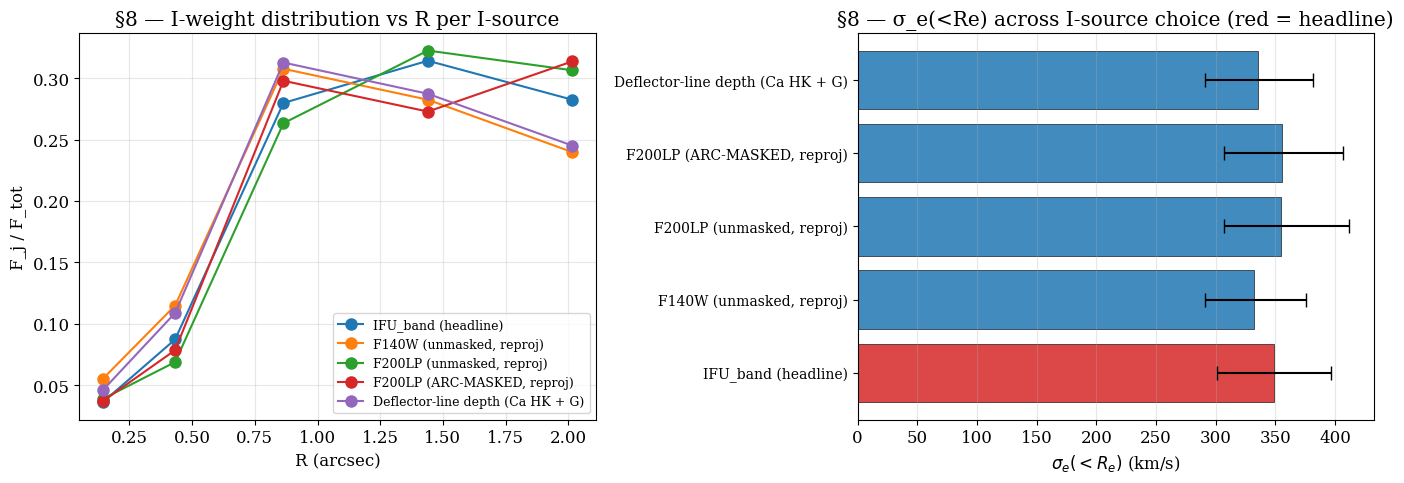

In [32]:
# §8 plot: I-source comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) I-maps side by side
ax = axes[0]
# Show 1D radial profiles for each I-source
for iname, r in isource_results.items():
    F = r['F_j']
    norm = F / F.sum()
    ax.plot(r_mid_ann, norm, 'o-', ms=8, lw=1.5, label=iname)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel('F_j / F_tot')
ax.set_title('§8 — I-weight distribution vs R per I-source')
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# (b) σ_e(<Re) bar chart across I-sources
ax = axes[1]
inames = list(isource_results.keys())
se_p50 = [np.median(np.concatenate([isource_results[n]['samples'][(sps, 'Re')][np.isfinite(isource_results[n]['samples'][(sps, 'Re')])] for sps in SPS_LIBS])) for n in inames]
se_p16 = [np.percentile(np.concatenate([isource_results[n]['samples'][(sps, 'Re')][np.isfinite(isource_results[n]['samples'][(sps, 'Re')])] for sps in SPS_LIBS]), 16) for n in inames]
se_p84 = [np.percentile(np.concatenate([isource_results[n]['samples'][(sps, 'Re')][np.isfinite(isource_results[n]['samples'][(sps, 'Re')])] for sps in SPS_LIBS]), 84) for n in inames]
cols_i = ['C3' if 'headline' in n else 'C0' for n in inames]
bars = ax.barh(range(len(inames)), se_p50,
               xerr=[np.array(se_p50)-np.array(se_p16), np.array(se_p84)-np.array(se_p50)],
               capsize=5, color=cols_i, alpha=0.85, edgecolor='black', lw=0.5)
ax.set_yticks(range(len(inames))); ax.set_yticklabels(inames, fontsize=10)
ax.set_xlabel(r'$\sigma_e(<R_e)$ (km/s)')
ax.set_title('§8 — σ_e(<Re) across I-source choice (red = headline)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s8_isource.png'), dpi=150, bbox_inches='tight')
plt.show()

## §9. Final summary plot + save

Dashboard with: σ(R) physics profile, cumulative σ_e(<R) vs R, bar chart of σ_e per aperture (filtered vs unfiltered), text panel.

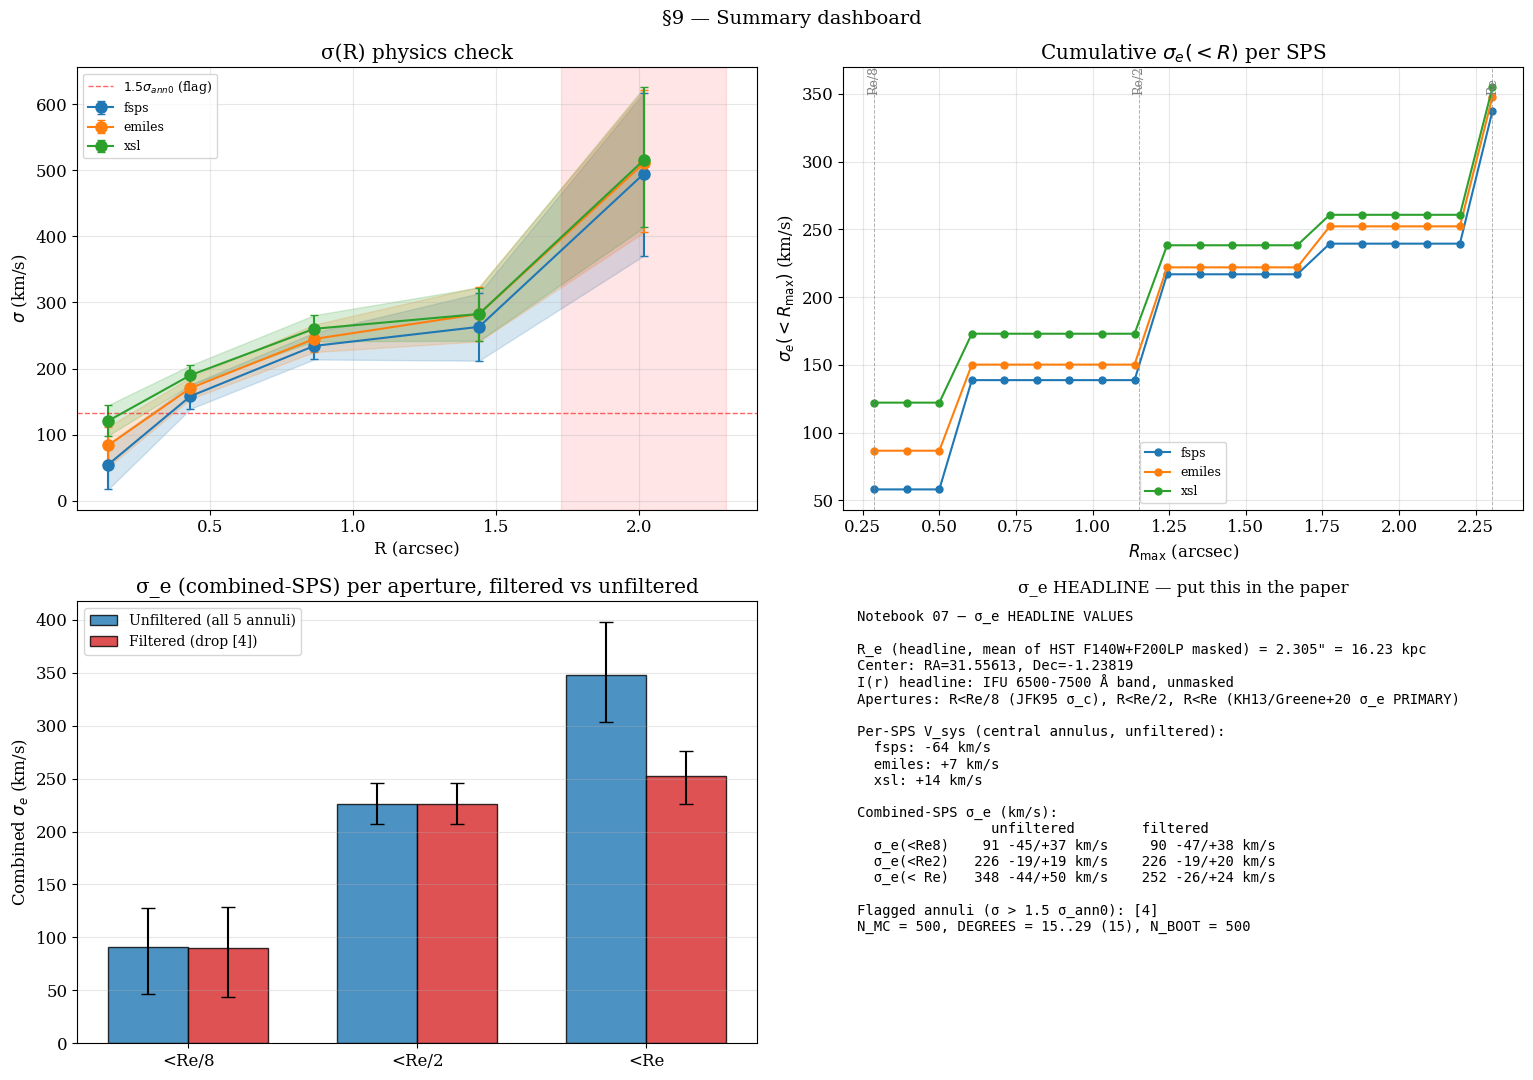

In [33]:
# §9 — summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# (1) σ(R) physics profile with flags
ax = axes[0, 0]
for sps in SPS_LIBS:
    d = sig_at_ann[sps]
    ax.fill_between(r_mid_ann, d['p16'], d['p84'], color=sps_colors[sps], alpha=0.18)
    ax.errorbar(r_mid_ann, d['p50'], yerr=[d['p50']-d['p16'], d['p84']-d['p50']],
                fmt='o-', ms=8, color=sps_colors[sps], capsize=3, label=sps)
ax.axhline(1.5 * sig_central, color='red', ls='--', lw=1.0, alpha=0.6,
           label=r'$1.5 \sigma_{ann0}$ (flag)')
for j in FLAGGED_ANNULI:
    ax.axvspan(r_edges[j], r_edges[j+1], color='red', alpha=0.1)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title('σ(R) physics check'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (2) Cumulative σ_e(<R) vs R per SPS
ax = axes[0, 1]
r_cum = np.linspace(R_E/8, R_E, 20)
for sps in SPS_LIBS:
    se_cum = []
    for r_max in r_cum:
        fake_aps = {'tag': r_max}
        # Compute σ_e(<r_max) for this SPS
        j_use = [j for j in range(len(annular_spectra)) if r_edges[j+1] <= r_max + 1e-6]
        if not j_use:
            se_cum.append(np.nan); continue
        F_sum = F_j[j_use].sum()
        V_sys = V_off_unf[sps]
        num_samples = np.zeros(N_MC)
        for j in j_use:
            V_arr = sam_unf[(sps, 'Re')] * 0  # placeholder shape
            d = bootstrap_results[(j, sps)]
            n_deg, n_boot = d['sig_boot'].shape
            rng_loc = np.random.default_rng(999+j)
            di = rng_loc.integers(0, n_deg, size=N_MC)
            bi = rng_loc.integers(0, n_boot, size=N_MC)
            Vd = d['V_boot'][di, bi]; Sd = d['sig_boot'][di, bi]
            num_samples += F_j[j] * ((Vd - V_sys)**2 + Sd**2)
        se = np.sqrt(num_samples / F_sum)
        se = se[np.isfinite(se)]
        se_cum.append(np.median(se) if len(se) else np.nan)
    ax.plot(r_cum, se_cum, 'o-', ms=5, color=sps_colors[sps], label=sps)
for tag, r_val in [('Re/8', R_E/8), ('Re/2', R_E/2), ('Re', R_E)]:
    ax.axvline(r_val, color='gray', ls='--', lw=0.7, alpha=0.6)
    ax.text(r_val, ax.get_ylim()[1]*0.95, tag, fontsize=9, color='gray',
            ha='center', rotation=90)
ax.set_xlabel(r'$R_{\rm max}$ (arcsec)'); ax.set_ylabel(r'$\sigma_e(<R_{\rm max})$ (km/s)')
ax.set_title(r'Cumulative $\sigma_e(<R)$ per SPS'); ax.grid(alpha=0.3); ax.legend(fontsize=9)

# (3) Bar chart: σ_e per aperture, filtered vs unfiltered, combined
ax = axes[1, 0]
x_pos = np.arange(3)
width = 0.35
unf_med = [np.median(np.concatenate([sam_unf[(sps,t)][np.isfinite(sam_unf[(sps,t)])] for sps in SPS_LIBS])) for t in APERTURES]
unf_lo = [np.percentile(np.concatenate([sam_unf[(sps,t)][np.isfinite(sam_unf[(sps,t)])] for sps in SPS_LIBS]), 16) for t in APERTURES]
unf_hi = [np.percentile(np.concatenate([sam_unf[(sps,t)][np.isfinite(sam_unf[(sps,t)])] for sps in SPS_LIBS]), 84) for t in APERTURES]
flt_med = [np.median(np.concatenate([sam_flt[(sps,t)][np.isfinite(sam_flt[(sps,t)])] for sps in SPS_LIBS])) for t in APERTURES]
flt_lo = [np.percentile(np.concatenate([sam_flt[(sps,t)][np.isfinite(sam_flt[(sps,t)])] for sps in SPS_LIBS]), 16) for t in APERTURES]
flt_hi = [np.percentile(np.concatenate([sam_flt[(sps,t)][np.isfinite(sam_flt[(sps,t)])] for sps in SPS_LIBS]), 84) for t in APERTURES]
ax.bar(x_pos - width/2, unf_med, width, yerr=[np.array(unf_med)-np.array(unf_lo), np.array(unf_hi)-np.array(unf_med)],
       capsize=5, color='C0', alpha=0.8, label='Unfiltered (all 5 annuli)', edgecolor='black')
ax.bar(x_pos + width/2, flt_med, width, yerr=[np.array(flt_med)-np.array(flt_lo), np.array(flt_hi)-np.array(flt_med)],
       capsize=5, color='C3', alpha=0.8, label=f'Filtered (drop {FLAGGED_ANNULI})', edgecolor='black')
ax.set_xticks(x_pos); ax.set_xticklabels(['<Re/8', '<Re/2', '<Re'])
ax.set_ylabel(r'Combined $\sigma_e$ (km/s)')
ax.set_title('σ_e (combined-SPS) per aperture, filtered vs unfiltered')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')

# (4) Text panel — headline summary
ax = axes[1, 1]; ax.axis('off')
txt = f'Notebook 07 — σ_e HEADLINE VALUES\n\n'
txt += f'R_e (headline, mean of HST F140W+F200LP masked) = {R_E:.3f}" = {R_E*KPC_PER_ARCSEC:.2f} kpc\n'
txt += f'Center: RA={RA_CENTER:.5f}, Dec={DEC_CENTER:.5f}\n'
txt += f'I(r) headline: IFU 6500-7500 Å band, unmasked\n'
txt += f'Apertures: R<Re/8 (JFK95 σ_c), R<Re/2, R<Re (KH13/Greene+20 σ_e PRIMARY)\n\n'
txt += f'Per-SPS V_sys (central annulus, unfiltered):\n'
for sps, V in V_off_unf.items():
    txt += f'  {sps}: {V:+.0f} km/s\n'
txt += f'\nCombined-SPS σ_e (km/s):\n'
txt += f'{"":>10} {"unfiltered":>15} {"filtered":>15}\n'
for i, tag in enumerate(APERTURES):
    txt += (f'  σ_e(<{tag:>3s})  '
            f'{unf_med[i]:>4.0f} -{unf_med[i]-unf_lo[i]:.0f}/+{unf_hi[i]-unf_med[i]:.0f} km/s   '
            f'{flt_med[i]:>4.0f} -{flt_med[i]-flt_lo[i]:.0f}/+{flt_hi[i]-flt_med[i]:.0f} km/s\n')
txt += f'\nFlagged annuli (σ > 1.5 σ_ann0): {FLAGGED_ANNULI}'
txt += f'\nN_MC = {N_MC}, DEGREES = {DEGREES[0]}..{DEGREES[-1]} ({len(DEGREES)}), N_BOOT = {N_BOOTSTRAP}'
ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top', ha='left',
        family='monospace', fontsize=10)
ax.set_title('σ_e HEADLINE — put this in the paper', fontsize=12)

fig.suptitle('§9 — Summary dashboard', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07_s9_dashboard.png'), dpi=160, bbox_inches='tight')
plt.show()

In [34]:
# Save to results/sigma_e_radial_clean.npz
save_dict = {}
for sps in SPS_LIBS:
    for tag in APERTURES:
        s = sam_unf[(sps, tag)]
        save_dict[f'sigma_e_samples_{sps}_{tag}'] = s
        s_good = s[np.isfinite(s)]
        if len(s_good):
            save_dict[f'sigma_e_{sps}_{tag}_p16'] = float(np.percentile(s_good, 16))
            save_dict[f'sigma_e_{sps}_{tag}_p50'] = float(np.percentile(s_good, 50))
            save_dict[f'sigma_e_{sps}_{tag}_p84'] = float(np.percentile(s_good, 84))
    save_dict[f'V_offset_{sps}'] = V_off_unf[sps]

# Combined posteriors
for tag in APERTURES:
    pool_u = np.concatenate([sam_unf[(sps, tag)][np.isfinite(sam_unf[(sps, tag)])] for sps in SPS_LIBS])
    pool_f = np.concatenate([sam_flt[(sps, tag)][np.isfinite(sam_flt[(sps, tag)])] for sps in SPS_LIBS])
    save_dict[f'sigma_e_samples_{tag}'] = pool_u
    save_dict[f'sigma_e_{tag}_p16'] = float(np.percentile(pool_u, 16))
    save_dict[f'sigma_e_{tag}_p50'] = float(np.percentile(pool_u, 50))
    save_dict[f'sigma_e_{tag}_p84'] = float(np.percentile(pool_u, 84))
    save_dict[f'sigma_e_filtered_samples_{tag}'] = pool_f
    save_dict[f'sigma_e_filtered_{tag}_p16'] = float(np.percentile(pool_f, 16))
    save_dict[f'sigma_e_filtered_{tag}_p50'] = float(np.percentile(pool_f, 50))
    save_dict[f'sigma_e_filtered_{tag}_p84'] = float(np.percentile(pool_f, 84))

# I-source table
save_dict['sigma_e_Isource_names'] = np.array(list(isource_results.keys()))
for iname, r in isource_results.items():
    safe = iname.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('/', '_')
    for tag in APERTURES:
        pool = np.concatenate([r['samples'][(sps,tag)][np.isfinite(r['samples'][(sps,tag)])] for sps in SPS_LIBS])
        if len(pool):
            save_dict[f'Isource_{safe}_{tag}_p16'] = float(np.percentile(pool, 16))
            save_dict[f'Isource_{safe}_{tag}_p50'] = float(np.percentile(pool, 50))
            save_dict[f'Isource_{safe}_{tag}_p84'] = float(np.percentile(pool, 84))

save_dict['Re_F140W'] = Re_f140
save_dict['Re_F200LP'] = Re_f200
save_dict['Re_IFU_band'] = Re_ifu
save_dict['Re_headline_arcsec'] = R_E
save_dict['Re_headline_kpc'] = R_E * KPC_PER_ARCSEC
save_dict['center_ra'] = RA_CENTER
save_dict['center_dec'] = DEC_CENTER
save_dict['flagged_annuli'] = np.array(FLAGGED_ANNULI)
save_dict['r_edges'] = r_edges
save_dict['F_j'] = F_j
save_dict['n_mc'] = N_MC
save_dict['n_bootstrap'] = N_BOOTSTRAP
save_dict['degree_range'] = np.array([int(DEGREES[0]), int(DEGREES[-1])])
save_dict['z_systemic'] = Z_SYSTEMIC
save_dict['method'] = 'radial_annular_Gultekin'
save_dict['I_source_headline'] = 'IFU_6500_7500A_unmasked'


# Cumulative-aperture σ_e (direct ppxf on I-weighted expanding circles)
for j, a in enumerate(cum_apertures):
    tag = f'cumR_{a["r_max"]:.3f}'.replace('.', 'p')
    for sps in SPS_LIBS:
        d = cum_bootstrap[(j, sps)]
        samp = d['sig_boot'].ravel()
        samp = samp[np.isfinite(samp)]
        if len(samp) == 0: continue
        save_dict[f'cum_sigma_samples_{sps}_{tag}'] = samp
        save_dict[f'cum_sigma_{sps}_{tag}_p50'] = float(np.percentile(samp, 50))
        save_dict[f'cum_sigma_{sps}_{tag}_p16'] = float(np.percentile(samp, 16))
        save_dict[f'cum_sigma_{sps}_{tag}_p84'] = float(np.percentile(samp, 84))
    pool = np.concatenate([cum_bootstrap[(j, sps)]['sig_boot'].ravel() for sps in SPS_LIBS])
    pool = pool[np.isfinite(pool)]
    if len(pool):
        save_dict[f'cum_sigma_samples_{tag}'] = pool
        save_dict[f'cum_sigma_{tag}_p50'] = float(np.percentile(pool, 50))
        save_dict[f'cum_sigma_{tag}_p16'] = float(np.percentile(pool, 16))
        save_dict[f'cum_sigma_{tag}_p84'] = float(np.percentile(pool, 84))
    save_dict[f'cum_R_max_{tag}'] = a['r_max']
    save_dict[f'cum_N_spax_{tag}'] = a['n_spax']

out_path = os.path.join(RESULTS_DIR, 'sigma_e_radial_clean.npz')
np.savez(out_path, **save_dict)
print(f'Saved: {out_path}')
print(f'Keys: {len(save_dict)}')

Saved: ../results/sigma_e_radial_clean.npz
Keys: 215
